# 03 - Identifiability and Variance Partition

This notebook analyzes relation-head identifiability, projection/norm trajectories, and variance-partition evolution over training.


In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Fix SSL certificates on macOS
import os, ssl, certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import os
from os.path import join
import torch
import torch as th
import torch.nn.functional as F
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle as pkl
from tqdm.auto import trange
from contextlib import redirect_stdout
import sys
sys.path.append("/Users/julianali/Desktop/DiffusionInterp/PixArt-alpha")
from diffusion import IDDPM
from diffusion.data.builder import build_dataset, build_dataloader, set_data_root
from diffusion.model.builder import build_model
from diffusion.utils.misc import set_random_seed, read_config, init_random_seed, DebugUnderflowOverflow
sys.path.append("/Users/julianali/Desktop/DiffusionInterp")
from utils.cv2_eval_utils import evaluate_pipeline_on_prompts, print_evaluation_summary
from utils.relation_shape_dataset_lib import ShapesDataset
from utils.variance_partition_with_effects import variance_partition_with_effects
from utils.pixart_sampling_utils import pipeline_inference_custom, \
    PixArtAlphaPipeline_custom, PixArtAlphaPipeline_custom_CLIP
from utils.pixart_utils import state_dict_convert
from utils.pixart_utils import construct_diffuser_pipeline_from_config, PixArt_model_configs
from utils.text_encoder_control_lib import RandomEmbeddingEncoder_wPosEmb
from utils.image_utils import pil_images_to_grid
from utils.attention_map_store_utils import replace_attn_processor, AttnProcessor2_0_Store, PixArtAttentionVisualizer_Store
from utils.cv2_eval_utils import find_classify_object_masks
from diffusers import AutoencoderKL, Transformer2DModel, PixArtAlphaPipeline, DPMSolverMultistepScheduler
from transformers import T5Tokenizer, T5EncoderModel

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = "cuda"
    compute_dtype = torch.float16
elif torch.backends.mps.is_available():
    device = "mps"
    compute_dtype = torch.float32
else:
    device = "cpu"
    compute_dtype = torch.float32
print(f"Using device: {device}, compute dtype: {compute_dtype}")

def saveallforms(figdir, fname, figh=None, fmts=("png", "pdf")):
    """Local replacement for circuit_toolkit.plot_utils.saveallforms"""
    os.makedirs(figdir, exist_ok=True)
    fig = figh if figh is not None else plt.gcf()
    for fmt in fmts:
        fig.savefig(os.path.join(figdir, f"{fname}.{fmt}"), bbox_inches='tight', dpi=150)

/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/c

Using device: mps, compute dtype: torch.float32


In [3]:
from itertools import product
def generate_all_prompt_collection(spatial_phrases, 
                               prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",):
    color_list = ['red', 'blue']
    shape_list = ['square', 'triangle', 'circle']
    prompt_collection = []
    scene_info_collection = []
    for color1, color2 in product(color_list, color_list):
        if color1 == color2:      # skip same‐color pairs
            continue
        for shape1, shape2 in product(shape_list, shape_list):
            if shape1 == shape2:
                continue
            for spatial_relationship, rel_text_collection in spatial_phrases.items():
                if spatial_relationship in ["in_front", "behind"]:
                    continue
                for rel_text in rel_text_collection:
                    prompt = prompt_template.format(color1=color1, shape1=shape1, rel_text=rel_text, color2=color2, shape2=shape2)
                    scene_info = {
                        "color1": color1,
                        "shape1": shape1,
                        "color2": color2,
                        "shape2": shape2,
                        "spatial_relationship": spatial_relationship
                    }
                    prompt_collection.append(prompt)
                    scene_info_collection.append(scene_info)
    return prompt_collection, scene_info_collection

In [4]:
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings
from experimental_scripts.generalization_profile_eval_cli import precompute_embeddings
def find_shape_index(tokens, shape):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = shape.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = shape.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

def find_word_index(tokens, word):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = word.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = word.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

## Section A - Environment Setup and Model Loading

Loads dependencies, resolves project paths, selects device/dtype, and builds the PixArt mini pipeline from checkpoint so later analysis cells can reuse a single initialized model.

### Suggested Notebook Split (Recommended)

For maintainability and faster Colab runs, this workflow is best split into separate notebooks:

1. **`01_setup_and_head_discovery.ipynb`** - environment setup, embedding cache, full head screening, and core visual diagnostics.
2. **`02_ablation_and_causality.ipynb`** - single/multi-head ablations, temporal/step ablations, and downstream reader tracing.
3. **`03_identifiability_and_variance_partition.ipynb`** - identifiability curves, norm tracking, and variance-partition evolution.
4. **`04_prompt_bias_and_attention_maps.ipynb`** - determiner ("the") bias analyses and cross-attention map comparisons.

Each notebook should begin by loading shared utilities and cached artifacts from `results/` to avoid recomputation.

In [ ]:
import time, gc, psutil

def mem_gb():
    m = psutil.virtual_memory()
    return m.available / (1024**3), m.used / (1024**3)

def mem_check(label, min_gb=2.0):
    avail, used = mem_gb()
    print(f"  [{label}] RAM: {avail:.1f} GB free, {used:.1f} GB used")
    if avail < min_gb:
        raise MemoryError(
            f"Only {avail:.1f} GB free — need at least {min_gb} GB. "
            f"Close other apps (browsers, Slack, etc.) and retry."
        )

_t0 = time.time()
mem_check("start", min_gb=3.0)

model_run_name = "objrel_T5_DiT_mini_pilot"
ckpt_name = "epoch_4000_step_160000.pth"
savedir = f"/Users/julianali/Desktop/DiffusionInterp/results/{model_run_name}"
config = read_config(join(savedir, 'config.py'))
print(f"[1/5] Config loaded — Model: {config.model}  ({time.time()-_t0:.1f}s)")

# Build ONLY the mini transformer (~100MB, not the full XL pipeline)
print("[2/5] Building DiT-mini transformer...")
from utils.pixart_utils import construct_diffuser_transformer_from_config
transformer = construct_diffuser_transformer_from_config(config)
print(f"       Transformer built ({time.time()-_t0:.1f}s)")
mem_check("after transformer")

# Load checkpoint into transformer, then free the checkpoint
print("[3/5] Loading trained checkpoint...")
ckptdir = join(savedir, "checkpoints")
ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
del ckpt; gc.collect()
print(f"       Checkpoint loaded ({time.time()-_t0:.1f}s)")
mem_check("after checkpoint")

# Load VAE directly from Stability AI (~300MB, NOT from the huge PixArt-XL bundle)
print("[4/5] Loading VAE from stabilityai/sd-vae-ft-ema...")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-ema", torch_dtype=compute_dtype)
print(f"       VAE loaded ({time.time()-_t0:.1f}s)")
mem_check("after VAE")

# Assemble pipeline manually — this avoids downloading PixArt-XL-2-512x512 (~10GB+)
print("[5/5] Assembling pipeline (no large downloads)...")
tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
scheduler = DPMSolverMultistepScheduler()
pipeline = PixArtAlphaPipeline_custom(
    transformer=transformer,
    vae=vae,
    scheduler=scheduler,
    tokenizer=tokenizer,
    text_encoder=None,
)

# Move lightweight components to device
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
pipeline.vae = pipeline.vae.to(device=device, dtype=compute_dtype)

gc.collect()
avail, used = mem_gb()
print(f"\nDone! Pipeline on {device} ({time.time()-_t0:.1f}s)")
print(f"RAM: {avail:.1f} GB free, {used:.1f} GB used")

  [start] RAM: 4.5 GB free, 7.4 GB used
[1/5] Config loaded — Model: PixArt_mini_2  (0.0s)
[2/5] Building DiT-mini transformer...
       Transformer built (0.0s)
  [after transformer] RAM: 4.5 GB free, 7.4 GB used
[3/5] Loading trained checkpoint...
       Checkpoint loaded (0.3s)
  [after checkpoint] RAM: 4.4 GB free, 7.3 GB used
[4/5] Loading VAE from stabilityai/sd-vae-ft-ema...


/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


       VAE loaded (0.6s)
  [after VAE] RAM: 4.3 GB free, 7.2 GB used
[5/5] Assembling pipeline (no large downloads)...

Done! Pipeline on mps (1.4s)
RAM: 4.1 GB free, 7.5 GB used


In [6]:
# Load pre-computed T5 embeddings from cache.
# If no cache exists, run the script in a SEPARATE PROCESS so T5 never enters this notebook.
import subprocess

cache_path = join(savedir, "t5_embedding_cache.pt")

if not os.path.exists(cache_path):
    avail, used = mem_gb()
    print(f"RAM before subprocess: {avail:.1f} GB free")
    if avail < 6.0:
        print(f"\n*** WARNING: Only {avail:.1f} GB free. The T5 subprocess needs ~6GB. ***")
        print("*** Close browsers, Slack, and other apps, then re-run this cell. ***\n")
    
    print("No embedding cache found. Running precomputation in a separate process...")
    print("(T5-XXL loads in a subprocess — this notebook's memory is unaffected)")
    print("This takes a few minutes the first time.\n")
    
    result = subprocess.run(
        [sys.executable, "/Users/julianali/Desktop/DiffusionInterp/scripts/precompute_t5_embeddings.py"],
    )
    if result.returncode != 0:
        raise RuntimeError(
            "Embedding precomputation failed!\n"
            "Try: 1) Close all other apps  2) Re-run this cell\n"
            "Or run the script directly in terminal:\n"
            f"  {sys.executable} /Users/julianali/Desktop/DiffusionInterp/scripts/precompute_t5_embeddings.py"
        )

print(f"Loading cached embeddings from {cache_path}...")
_cache = torch.load(cache_path, map_location="cpu", weights_only=False)
embedding_allrel_allobj = _cache["embedding_allrel_allobj"]
del _cache; gc.collect()
avail, _ = mem_gb()
print(f"Loaded {len(embedding_allrel_allobj)} embeddings. ({avail:.1f} GB free)")

Loading cached embeddings from /Users/julianali/Desktop/DiffusionInterp/results/objrel_T5_DiT_mini_pilot/t5_embedding_cache.pt...
Loaded 1057 embeddings. (4.1 GB free)


## Section B - Build/Load Embedding Cache and Token Features

Creates (or loads) cached T5 embeddings, extracts token-level vectors for objects/relations, and projects them into model space for head-alignment and downstream causal analysis.

In [7]:
# Extract word vectors from the pre-computed cached embeddings
dataset_tmp = ShapesDataset(num_images=10000)
prompt_collection_all, scene_info_collection_all = generate_all_prompt_collection(dataset_tmp.spatial_phrases,
                                prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",)
prompt_scene_info_all_df = pd.DataFrame(scene_info_collection_all)
prompt_scene_info_all_df["prompt"] = prompt_collection_all

wordvec_obj1_col = []
wordvec_obj2_col = []
for row in prompt_scene_info_all_df.itertuples():
    tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
    token_ids = tokenized['input_ids'][0]
    tokens = [pipeline.tokenizer.decode([token_id]) for token_id in token_ids]
    
    shape1_mask_idx = find_shape_index(tokens, row.shape1)
    shape2_mask_idx = find_shape_index(tokens, row.shape2)
    cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
    if shape1_mask_idx is None or shape2_mask_idx is None:
        print(f"Prompt: {row.prompt}")
        print(f"Shape1 ({row.shape1}) at index: {shape1_mask_idx}")
        print(f"Shape2 ({row.shape2}) at index: {shape2_mask_idx}")
        raise ValueError("Shape index not found")
    wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
    wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
with torch.no_grad():
    wordvec_obj1_mat_proj = pipeline.transformer.caption_projection(wordvec_obj1_mat.to(dtype=compute_dtype, device=device))
    wordvec_obj2_mat_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
print(f"Extracted word vectors: obj1={wordvec_obj1_mat.shape}, obj2={wordvec_obj2_mat.shape}")
print(f"Projected: obj1_proj={wordvec_obj1_mat_proj.shape}, obj2_proj={wordvec_obj2_mat_proj.shape}")

Extracted word vectors: obj1=torch.Size([264, 4096]), obj2=torch.Size([264, 4096])
Projected: obj1_proj=torch.Size([264, 384]), obj2_proj=torch.Size([264, 384])


In [8]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]

var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
             "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
             "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

Total R2 (all features): 0.753982
Total R² (all features): 0.7540


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,spatial_relationship,8,7,247,4287.382813,517.440110,0.120689,5.174401e+02,1.206890e-01,3.291159e-01,0.009901
1,color2shape2,6,5,247,4287.382813,2478.810885,0.578164,5.403549e+01,1.260338e-02,4.873296e-02,0.009901
2,color1shape1,6,5,247,4287.382813,1051.531256,0.245262,2.134541e+01,4.978657e-03,1.983557e-02,0.514851
3,shape2,3,2,247,4287.382813,2204.805622,0.514254,1.709012e-13,3.986142e-17,1.620266e-16,1.000000
4,color1,2,1,247,4287.382813,200.811887,0.046838,8.054627e-14,1.878682e-17,7.636365e-17,1.000000
5,color2,2,1,247,4287.382813,200.811887,0.046838,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
6,shape1,3,2,247,4287.382813,810.216076,0.188977,-4.825689e-13,-1.125556e-16,-4.575099e-16,1.000000


In [9]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]

var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj1_mat.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
             "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
            #  "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

Total R2 (all features): 0.757099
Total R² (all features): 0.7571


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,spatial_relationship,8,7,249,3454.200772,275.282371,0.079695,2.752824e+02,7.969495e-02,2.470428e-01,0.009901
1,shape2,3,2,249,3454.200772,703.267542,0.203598,1.897958e+02,5.494639e-02,1.844784e-01,0.009901
2,color1shape1,6,5,249,3454.200772,2150.094347,0.622458,6.427153e+01,1.860677e-02,7.115195e-02,0.009901
3,color2,2,1,249,3454.200772,226.763259,0.065649,1.121765e-12,3.247538e-16,1.336981e-15,1.000000
4,shape1,3,2,249,3454.200772,1859.059553,0.538203,8.298863e-13,2.402542e-16,9.891042e-16,1.000000


In [10]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]

var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
            #  "shape2": prompt_scene_info_all_df["shape2"],
            #  "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

Total R2 (all features): 0.749004
Total R² (all features): 0.7490


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,color2shape2,6,5,249,4287.382813,2478.810885,0.578164,1883.608754,0.439338,0.636413,0.009901
1,spatial_relationship,8,7,249,4287.382813,517.440110,0.120689,517.440110,0.120689,0.324707,0.009901
2,shape1,3,2,249,4287.382813,810.216076,0.188977,215.013945,0.050150,0.166531,0.009901


In [11]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]
print("shape2, T5 embedding, caption projection")
var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
            #  "shape2": prompt_scene_info_all_df["shape2"],
            #  "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

shape2, T5 embedding, caption projection
Total R2 (all features): 0.619995
Total R² (all features): 0.6200


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,color2shape2,6,5,249,11125.028957,3809.018882,0.342383,3340.579401,0.300276,0.441400,0.009901
1,spatial_relationship,8,7,249,11125.028957,2201.632767,0.197899,2201.632767,0.197899,0.342443,0.009901
2,shape1,3,2,249,11125.028957,1355.255459,0.121820,886.815978,0.079714,0.173397,0.009901


## Section C - Head Screening (Alignment Scan)

Scores all cross-attention heads by alignment to relation directions and saves a ranked table used to pick candidate relation heads for visualization and ablation.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
def ramp_alignment_metrics(M, dvec, eps=1e-12):
    """
    Returns:
      cosine     : [-1, 1] alignment with spatial direction (scale-free)
      projection : signed magnitude of alignment (units of M)
    """
    H, W = M.shape
    d = np.array(dvec)
    d = d / np.linalg.norm(d)
    
    # coordinate grid
    xs = np.linspace(-1, 1, W)
    ys = np.linspace(-1, 1, H)
    X, Y = np.meshgrid(xs, ys)

    # ramp template
    T = d[0] * X + d[1] * Y
    T = T - T.mean()                      # remove DC (important!)
    T_norm = np.linalg.norm(T) + eps
    T_unit = T / T_norm                   # unit template

    # centered map
    # A = M.astype(float)
    A = M - M.mean()
    A_norm = np.linalg.norm(A) + eps

    # (1) signed projection magnitude
    projection = np.sum(A * T / T_norm)

    # (2) cosine / correlation
    cosine = projection / A_norm

    return dict(
        cosine=cosine,
        projection=projection,
        energy=A_norm,
        template_norm=T_norm,
    )


def visualize_direction_vectors(H=8, W=8):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    # Visualize the template ramps in 2x4 subplots
    H, W = 8, 8  # set the dimensions of the grid (adjust if appropriate)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for idx, (name, dvec) in enumerate(direction_vector.items()):
        xs = np.linspace(-1, 1, W)
        ys = np.linspace(-1, 1, H)
        X, Y = np.meshgrid(xs, ys)
        d = np.array(dvec)
        d = d / np.linalg.norm(d)
        T = d[0] * X + d[1] * Y
        T = T - T.mean()
        
        ax = axes[idx // 4, idx % 4]
        im = ax.imshow(T, cmap='coolwarm')
        ax.set_title(name)
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# visualize_direction_vectors()
# inner_prod_mat[:, i_word:i_word+1].view(8, 8)
# plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
# plt.title(f"{levels_map['spatial_relationship'][i_word]}")
def eval_ramp_alignment_all(inner_prod_mat, spatial_relationship_levels, eps=1e-12):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    i_word = 1
    align_dict_list = []
    for i_word in range(len(spatial_relationship_levels)):
        rel_name = spatial_relationship_levels[i_word]
        dvec = direction_vector[rel_name]
        align_dict = ramp_alignment_metrics(inner_prod_mat[:, i_word:i_word+1].view(8, 8).detach().cpu().numpy(), dvec, eps=1e-12)
        align_dict["rel_name"] = rel_name
        align_dict["dvec"] = (dvec[0], dvec[1])
        align_dict["dir_idx"] = i_word
        align_dict_list.append(align_dict)
    # align_dict_list
    align_df = pd.DataFrame(align_dict_list)
    return align_df

In [13]:
from diffusion.model.nets.PixArt import get_2d_sincos_pos_embed

In [14]:
from tqdm import tqdm
from itertools import product
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
print(f"Model: {config.model} — {layer_num} layers, {head_num} heads, hidden_size={hidden_size}, head_dim={head_dim}")
align_df_list = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num))):
    target_embedding_direction = effect_vecs["spatial_relationship"][:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map["spatial_relationship"])
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list.append(align_df)
align_df_allheads = pd.concat(align_df_list)

Model: PixArt_mini_2 — 6 layers, 6 heads, hidden_size=384, head_dim=64


0it [00:00, ?it/s]

36it [00:00, 338.77it/s]


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
figroot = "/Users/julianali/Desktop/DiffusionInterp/Figures/DiT_T5_attn_head_finding"
figdir = join(figroot, model_run_name)
os.makedirs(figdir, exist_ok=True)

Top spatial heads (by |cosine| > 0.7):
  Layer 0, Head 0: cosine=0.97, proj=88.1, energy=91
  Layer 1, Head 2: cosine=-0.98, proj=-42.8, energy=44
  Layer 2, Head 0: cosine=-0.78, proj=-12.9, energy=16
  Layer 2, Head 1: cosine=-0.78, proj=-16.9, energy=21
  Layer 2, Head 2: cosine=-0.92, proj=-18.6, energy=20
  Layer 2, Head 5: cosine=-0.77, proj=-9.3, energy=12
  Layer 3, Head 4: cosine=-0.83, proj=-7.8, energy=9
  Layer 3, Head 5: cosine=-0.75, proj=-6.0, energy=8


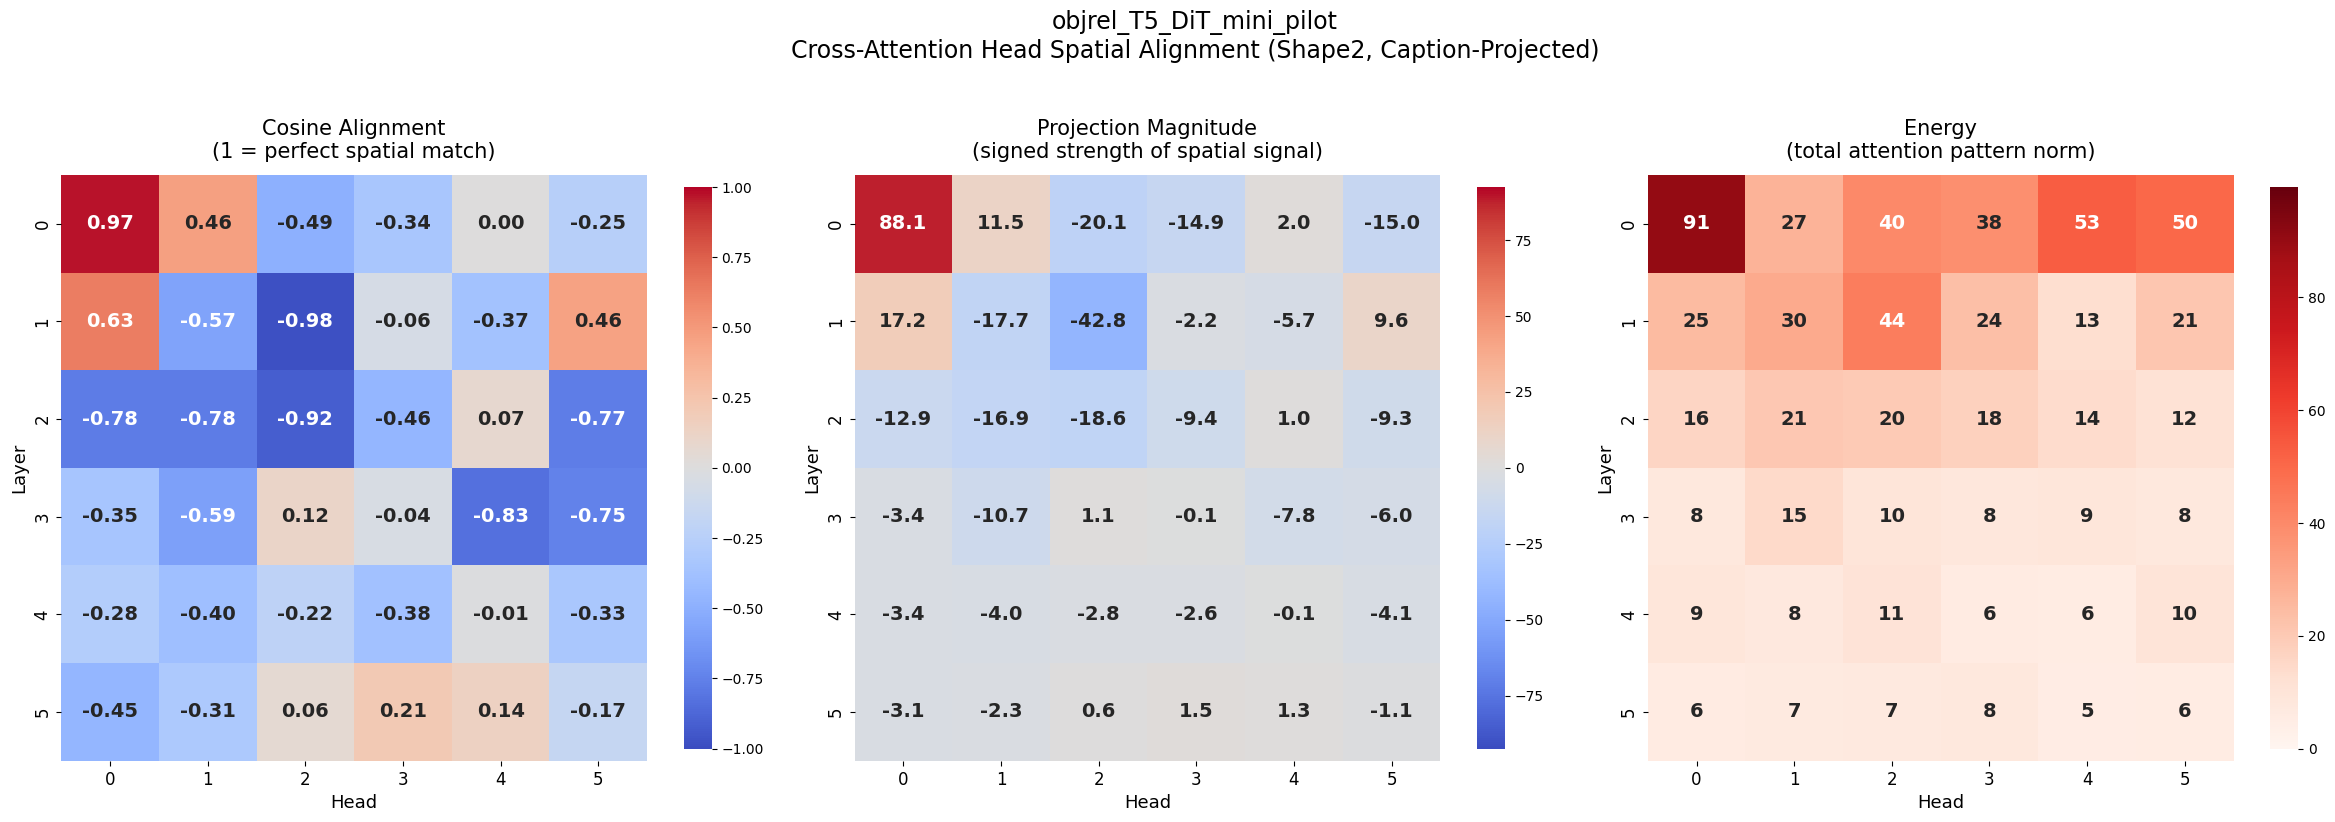

In [16]:
align_df_allheads.to_csv(join(figdir, f"{model_run_name}_align_score_allheads_shape2_MLP_proj_rel_factor.csv"), index=False)
head_align_synopsis = align_df_allheads.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)

metrics = ["cosine", "projection", "energy"]
titles = [
    "Cosine Alignment\n(1 = perfect spatial match)",
    "Projection Magnitude\n(signed strength of spatial signal)",
    "Energy\n(total attention pattern norm)",
]
n_metrics = len(metrics)

# Use data-driven color limits for projection so weak heads aren't washed out
proj_max = max(abs(head_align_synopsis["projection"].min()), abs(head_align_synopsis["projection"].max()))
energy_max = head_align_synopsis["energy"].max()

fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 8), squeeze=False)
for idx, metric, clim, fmt, title in zip(
    range(n_metrics), metrics,
    [(-1, 1), (-proj_max * 1.05, proj_max * 1.05), (0, energy_max * 1.1)],
    [".2f", ".1f", ".0f"],
    titles,
):
    heatmap_data = head_align_synopsis[metric].unstack(level="head_idx")
    ax = axes[0, idx]
    cmap = "Reds" if metric == "energy" else "coolwarm"
    sns.heatmap(
        heatmap_data, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar=True,
        vmin=clim[0], vmax=clim[1],
        annot_kws={"size": 14, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.tick_params(labelsize=12)

# Highlight top spatial heads
print("Top spatial heads (by |cosine| > 0.7):")
for _, row in head_align_synopsis.iterrows():
    if abs(row["cosine"]) > 0.7:
        l, h = row.name
        print(f"  Layer {l}, Head {h}: cosine={row['cosine']:.2f}, proj={row['projection']:.1f}, energy={row['energy']:.0f}")

fig.suptitle(
    f"{model_run_name}\nCross-Attention Head Spatial Alignment (Shape2, Caption-Projected)",
    fontsize=17, y=1.03,
)
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_all_heads_align_score_synopsis_shape2_MLP_proj_rel_factor")
plt.show()

### Section C.1 - Shape1/Object1 Alignment Scan

Repeats the head-alignment computation for object1 (shape1) features to compare whether heads encode object identity vs spatial relation.

In [17]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]
print("shape2, T5 embedding, caption projection")
var_part_df_S1, intercept_S1, effect_vecs_S1, levels_map_S1, R2_total_S1 = variance_partition_with_effects(wordvec_obj1_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
            #  "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
            #  "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df_S1

shape2, T5 embedding, caption projection
Total R2 (all features): 0.670111
Total R² (all features): 0.6701


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,color1shape1,6,5,249,10202.900793,4351.159422,0.426463,3799.699106,0.372414,0.530275,0.009901
1,spatial_relationship,8,7,249,10202.900793,1668.141067,0.163497,1668.141067,0.163497,0.331377,0.009901
2,shape2,3,2,249,10202.900793,1369.238377,0.134201,817.778060,0.080152,0.195472,0.009901


In [18]:
from tqdm import tqdm
from itertools import product
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
align_df_list = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num))):
    target_embedding_direction = effect_vecs_S1["spatial_relationship"][:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_S1["spatial_relationship"])
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list.append(align_df)
align_df_allheads_S1 = pd.concat(align_df_list)

0it [00:00, ?it/s]

36it [00:00, 275.40it/s]


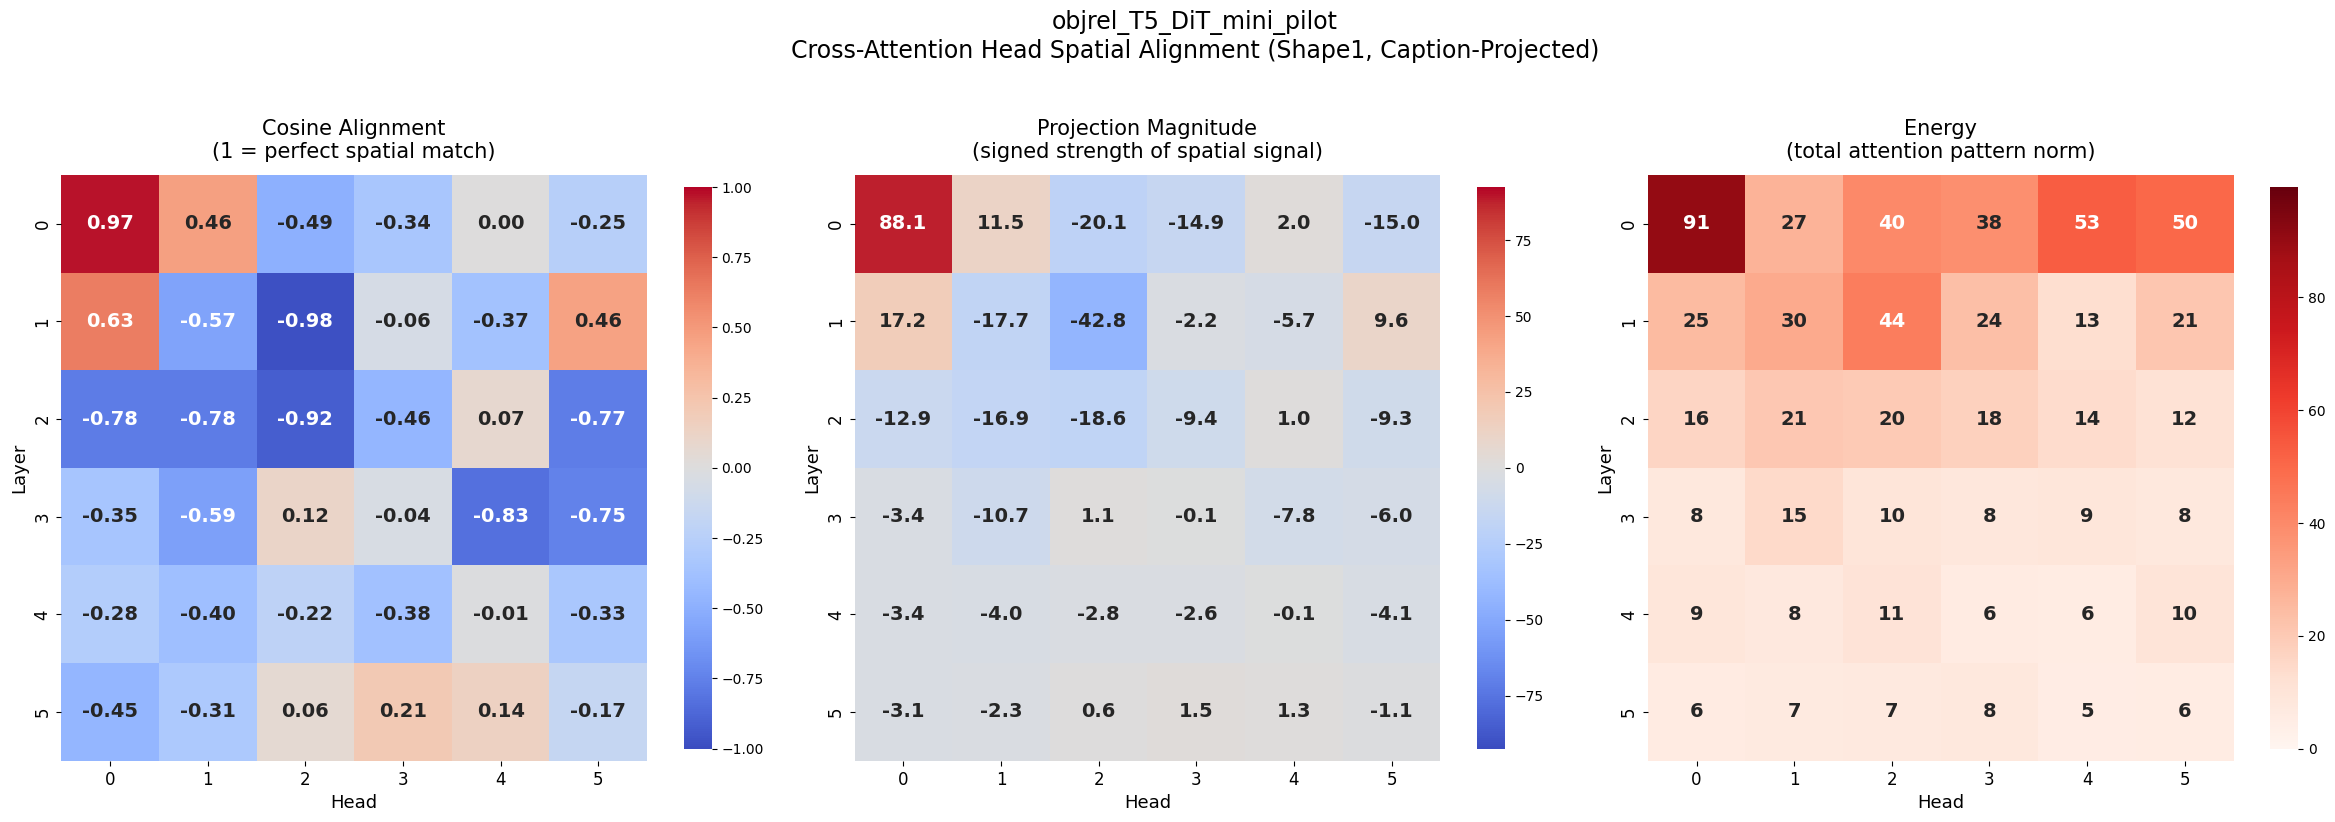

In [19]:
align_df_allheads.to_csv(join(figdir, f"{model_run_name}_align_score_allheads_shape1_MLP_proj_rel_factor.csv"), index=False)
head_align_synopsis = align_df_allheads.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)

metrics = ["cosine", "projection", "energy"]
titles = [
    "Cosine Alignment\n(1 = perfect spatial match)",
    "Projection Magnitude\n(signed strength of spatial signal)",
    "Energy\n(total attention pattern norm)",
]
n_metrics = len(metrics)

proj_max = max(abs(head_align_synopsis["projection"].min()), abs(head_align_synopsis["projection"].max()))
energy_max = head_align_synopsis["energy"].max()

fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 8), squeeze=False)
for idx, metric, clim, fmt, title in zip(
    range(n_metrics), metrics,
    [(-1, 1), (-proj_max * 1.05, proj_max * 1.05), (0, energy_max * 1.1)],
    [".2f", ".1f", ".0f"],
    titles,
):
    heatmap_data = head_align_synopsis[metric].unstack(level="head_idx")
    ax = axes[0, idx]
    cmap = "Reds" if metric == "energy" else "coolwarm"
    sns.heatmap(
        heatmap_data, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar=True,
        vmin=clim[0], vmax=clim[1],
        annot_kws={"size": 14, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.tick_params(labelsize=12)

fig.suptitle(
    f"{model_run_name}\nCross-Attention Head Spatial Alignment (Shape1, Caption-Projected)",
    fontsize=17, y=1.03,
)
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_all_heads_align_score_synopsis_shape1_MLP_proj_rel_factor")
plt.show()

### Section C.2 - Selective Head Visualization

Generates focused plots for selected high-value heads/layers so you can quickly inspect spatial ramp structure without scanning all heads.

Text(0.5, 0.98, 'objrel_T5_DiT_mini_pilot\nL0H0 pos embed inner product with spatial relation factors in Caption Projection')

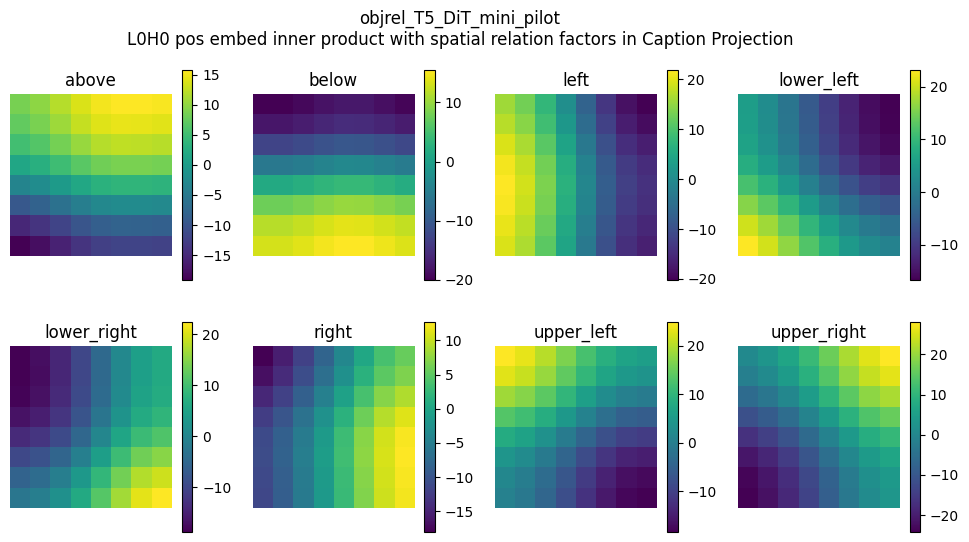

In [20]:
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
# Pick a layer/head to inspect — update after seeing the heatmaps above
layer_idx, head_idx = 0,0
target_embedding_direction = effect_vecs["spatial_relationship"][:, :]
target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
axs = axs.flatten()
for i_word in range(len(effect_vecs["spatial_relationship"])):
    plt.sca(axs[i_word])
    attn_score = inner_prod_mat[:, i_word:i_word+1]
    plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
    plt.title(f"{levels_map['spatial_relationship'][i_word]}")
    plt.axis("off")
    plt.colorbar()
plt.suptitle(f"{model_run_name}\nL{layer_idx}H{head_idx} pos embed inner product with spatial relation factors in Caption Projection")

In [21]:
from utils.pixart_utils import PixArt_model_configs
def compute_vis_pos_embed_inner_prod(pipeline, config, layer_idx, head_idx, feature_vecs, levels_names=None, 
                                   model_run_name="model", device=device, visualize=True):
    """
    Visualize the inner product between 2D positional embeddings and target effect vectors for specified head/layer.
    """
    transformer_config = PixArt_model_configs[config.model] if config is not None else PixArt_model_configs["PixArt_mini_2"]
    hidden_size = transformer_config["hidden_size"]
    head_num = transformer_config["num_heads"]
    layer_num = transformer_config["depth"]
    base_size = 16 // 2
    head_dim = hidden_size // head_num

    target_embedding_direction = feature_vecs[:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]

    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]

    inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
    if visualize:
        num_levels = len(feature_vecs)
        nrows, ncols = (2, 4) if num_levels == 8 else (1, num_levels)
        fig, axs = plt.subplots(nrows, ncols, figsize=(12, 6))
        axs = axs.flatten() if hasattr(axs, "flatten") else [axs]

        for i_word in range(num_levels):
            plt.sca(axs[i_word])
            attn_score = inner_prod_mat[:, i_word:i_word+1]
            plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
            if levels_names is not None:
                plt.title(f"{levels_names[i_word]}")
            else:
                plt.title(f"{i_word}")
            plt.axis("off")
            plt.colorbar()
        plt.suptitle(f"{model_run_name}\nL{layer_idx}H{head_idx} pos embed inner product with {len(feature_vecs)} factors in Caption Projection")
        plt.tight_layout()
        plt.show()
    else:
        fig = None
    return inner_prod_mat, fig

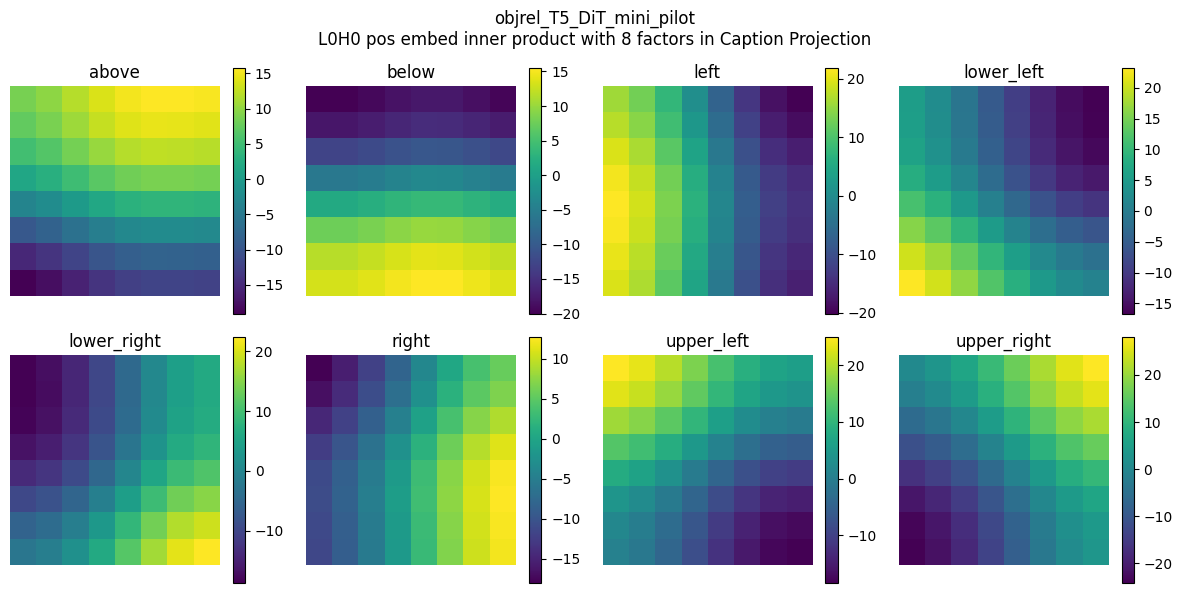

In [22]:
# Example: inspect the strongest spatial head
inner_prod_mat, fig = compute_vis_pos_embed_inner_prod(pipeline, config, 0, 0, 
                                 effect_vecs["spatial_relationship"], 
                                 levels_names=levels_map["spatial_relationship"], 
                                 model_run_name=model_run_name, 
                                 device=device, visualize=True);

Visualizing 8 top spatial heads: [(0, 0), (1, 2), (2, 0), (2, 1), (2, 2), (2, 5), (3, 4), (3, 5)]



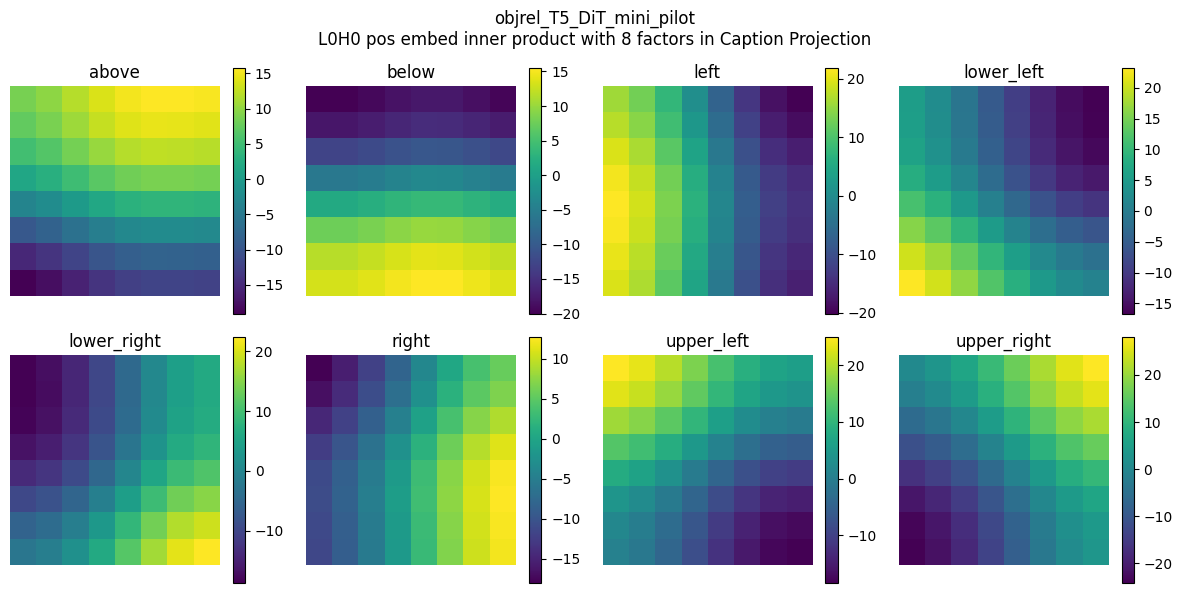

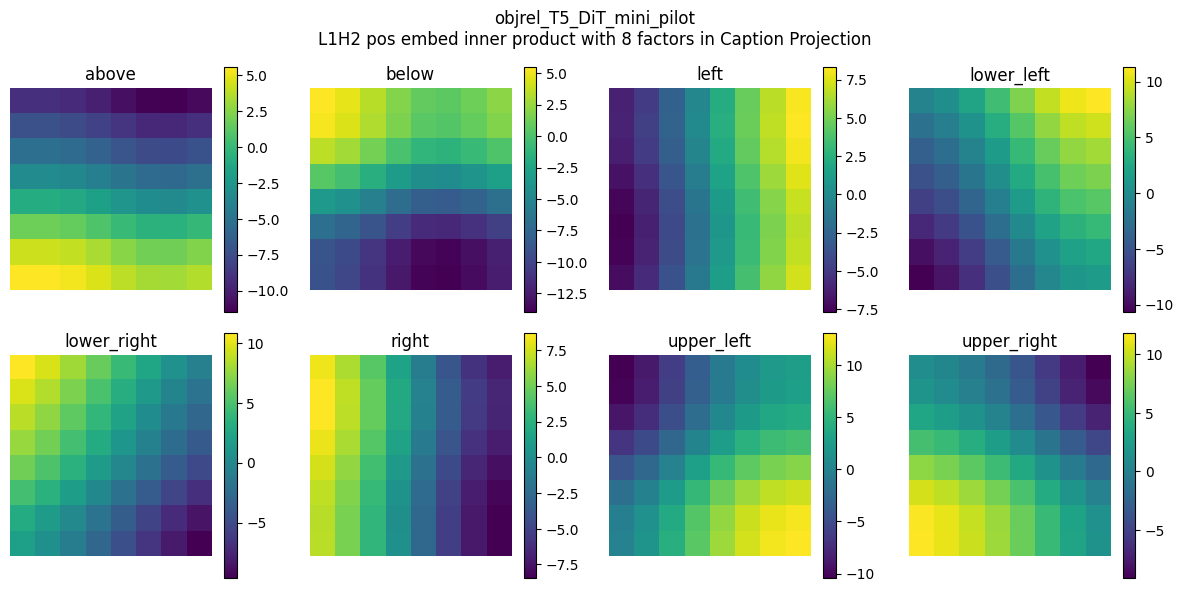

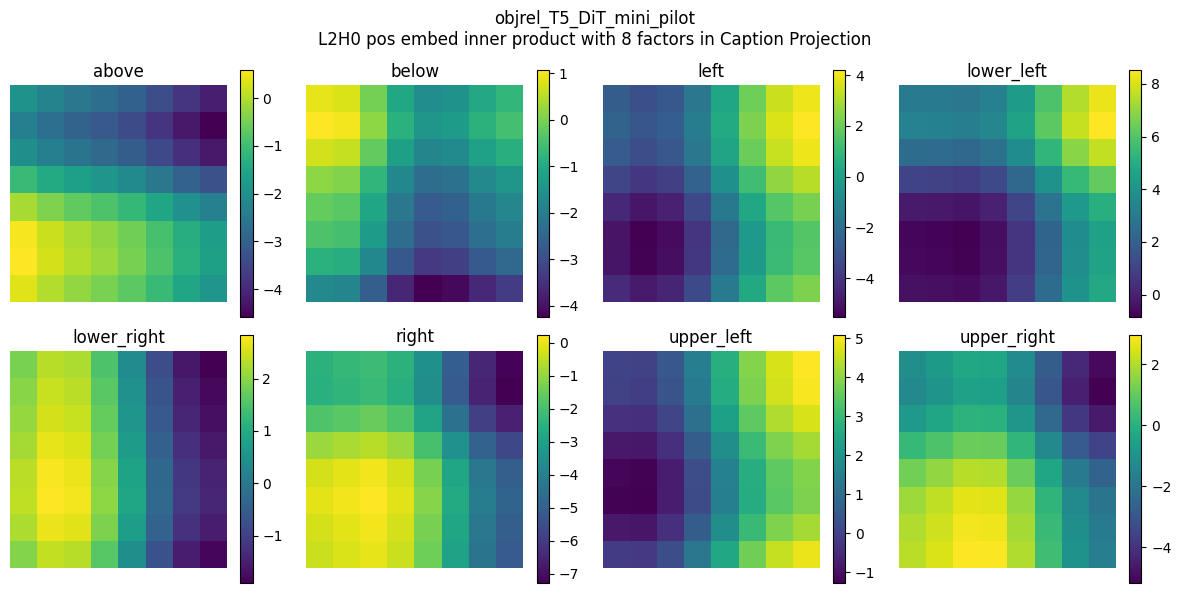

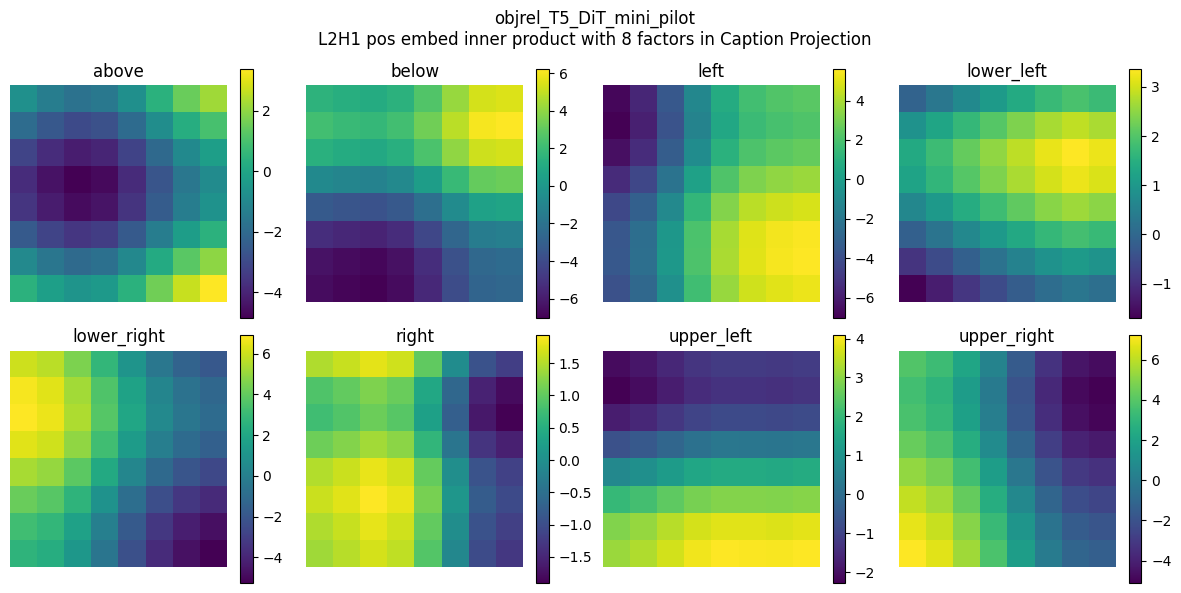

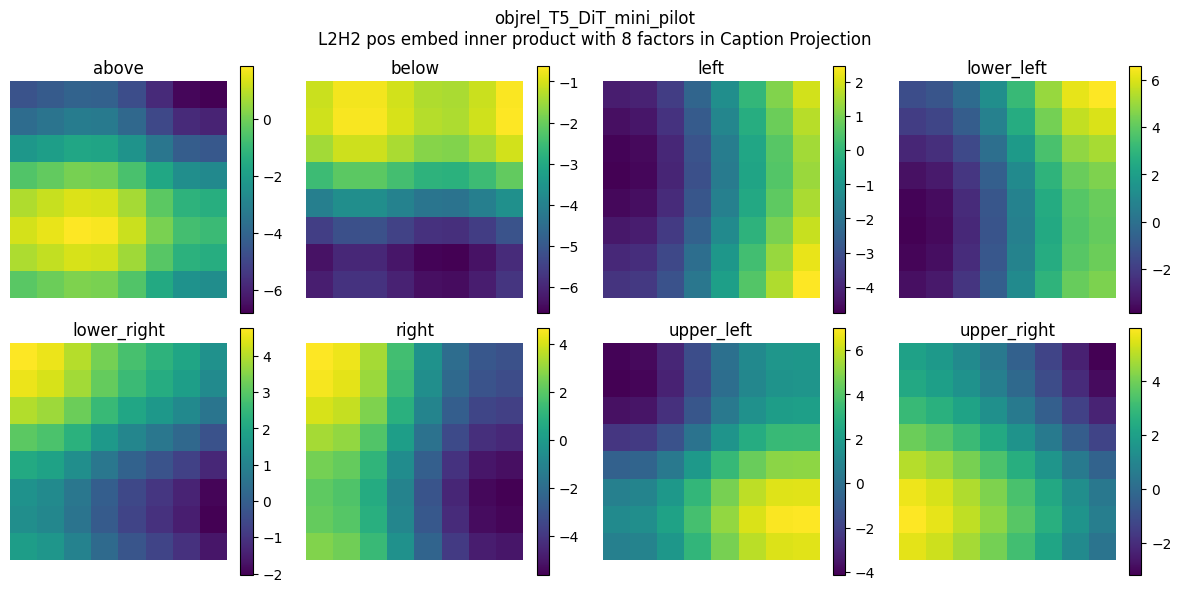

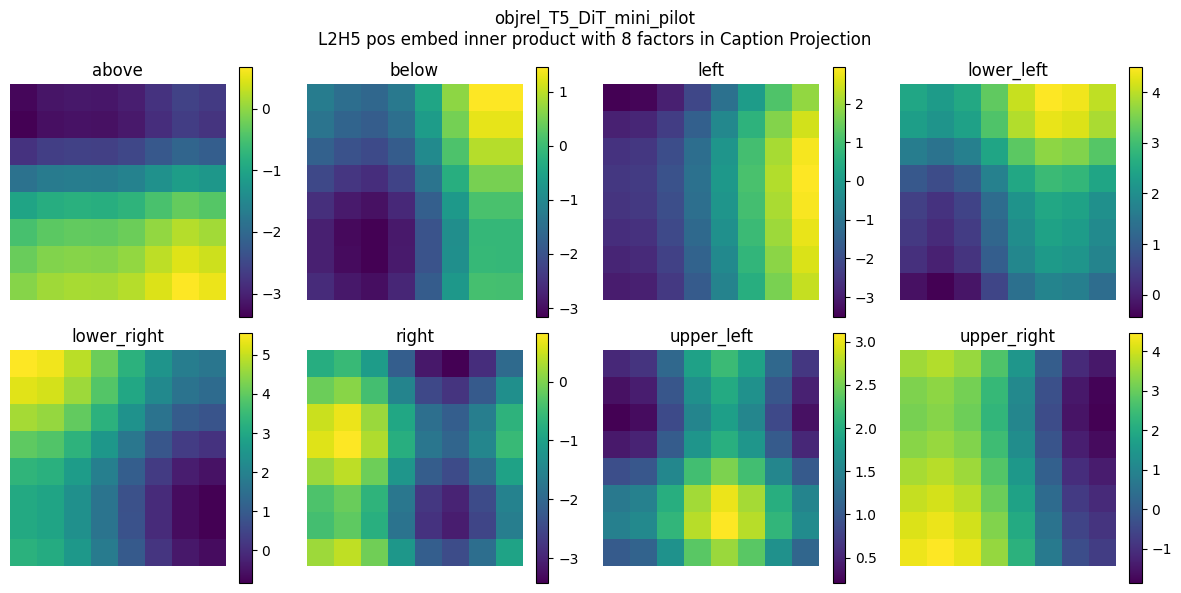

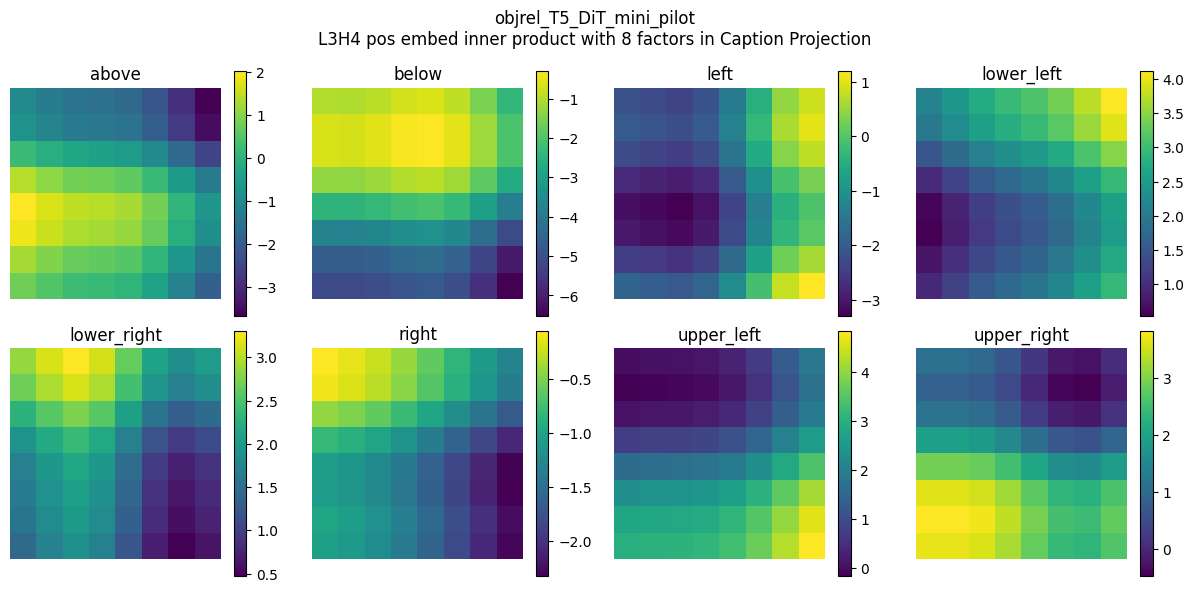

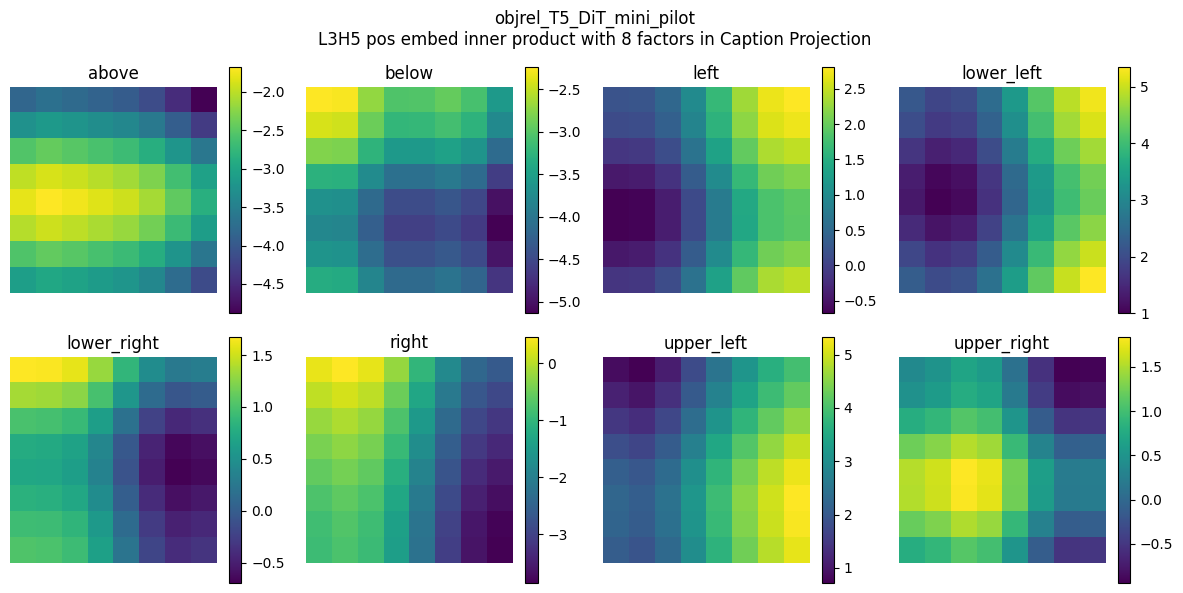

In [23]:
# Visualize the top spatial heads found from the heatmap above
# Pick heads with |cosine| > 0.7 automatically
top_heads = []
for _, row in head_align_synopsis.iterrows():
    if abs(row["cosine"]) > 0.7:
        top_heads.append(row.name)  # (layer_idx, head_idx)

if not top_heads:
    top_heads = [(0, 0), (1, 2), (2, 3)]  # fallback
    
print(f"Visualizing {len(top_heads)} top spatial heads: {top_heads}\n")
for layer_idx, head_idx in top_heads:
    inner_prod_mat, fig = compute_vis_pos_embed_inner_prod(pipeline, config, layer_idx, head_idx, 
                                     effect_vecs["spatial_relationship"], 
                                     levels_names=levels_map["spatial_relationship"], 
                                     model_run_name=model_run_name, 
                                     device=device, visualize=True);

### Trace spatial heads through training

**Goal:** See how cross-attention head spatial alignment evolves across checkpoints.

**Key insight:** T5 embeddings are frozen → same raw embeddings for all checkpoints.  
But the **caption projection (MLP)** and **cross-attention weights** are trained → we must:
1. Load each checkpoint
2. Project cached T5 embeddings through that checkpoint's caption_projection
3. Run variance partition on projected embeddings (effect_vecs differ per checkpoint)
4. Run head alignment using that checkpoint's attn2 weights + effect_vecs

In [24]:
# Define checkpoints to trace (epoch, step) and load order
ckpt_files = [
    "epoch_100_step_4000.pth",
    "epoch_250_step_10000.pth",
    "epoch_500_step_20000.pth",
    "epoch_1000_step_40000.pth",
    "epoch_2000_step_80000.pth",
    "epoch_4000_step_160000.pth",
]
# Fine-grained checkpoints for 500–1000 (relation head emergence)
ckpt_files_emergence = [
    "epoch_500_step_20000.pth",
    "epoch_600_step_24000.pth",
    "epoch_700_step_28000.pth",
    "epoch_750_step_30000.pth",
    "epoch_800_step_32000.pth",
    "epoch_900_step_36000.pth",
    "epoch_1000_step_40000.pth",
]
# Extended ablation: emergence + later checkpoints (2000, 4000) where relation head should be stronger
ckpt_files_ablation = ckpt_files_emergence + [
    "epoch_2000_step_80000.pth",
    "epoch_4000_step_160000.pth",
]
ckptdir = join(savedir, "checkpoints")
print(f"Full trace: {len(ckpt_files)} checkpoints | Emergence (500–1000): {len(ckpt_files_emergence)} | Ablation sweep: {len(ckpt_files_ablation)}")

Full trace: 6 checkpoints | Emergence (500–1000): 7 | Ablation sweep: 9


In [25]:
# For each checkpoint: load, project embeddings, variance partition, head alignment
# Results stored in evolution_records (list of DataFrames, one per checkpoint)

n_perm_evolution = 50  # Reduce for faster run (original uses 100)
evolution_records = []
var_part_evolution = []
q_norms_evolution = []
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num

for ckpt_name in tqdm(ckpt_files, desc="Checkpoints"):
    # 1. Load checkpoint into transformer (reuse existing pipeline structure)
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    
    # 2. Project cached T5 embeddings through this checkpoint's caption_projection
    wordvec_obj1_col, wordvec_obj2_col = [], []
    for row in prompt_scene_info_all_df.itertuples():
        cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
        tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
        tokens = [pipeline.tokenizer.decode([token_id]) for token_id in tokenized['input_ids'][0]]
        shape1_mask_idx = find_shape_index(tokens, row.shape1)
        shape2_mask_idx = find_shape_index(tokens, row.shape2)
        wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
        wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
    wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
    wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
    with torch.no_grad():
        wordvec_obj1_mat_proj = pipeline.transformer.caption_projection(wordvec_obj1_mat.to(dtype=compute_dtype, device=device))
        wordvec_obj2_mat_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
    
    # 3. Variance partition on projected embeddings (Shape2)
    df = prompt_scene_info_all_df.copy()
    df["color1shape1"] = df["color1"] + "_" + df["shape1"]
    df["color2shape2"] = df["color2"] + "_" + df["shape2"]
    var_part_df_ckpt, _, effect_vecs_ckpt, levels_map_ckpt, R2_total_ckpt = variance_partition_with_effects(
        wordvec_obj2_mat_proj.float().cpu().numpy(),
        {"spatial_relationship": df["spatial_relationship"], "shape1": df["shape1"], "color2shape2": df["color2shape2"]},
        metric="euclidean", n_perm=n_perm_evolution, verbose=False)
    
    # 4. Head alignment for this checkpoint
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_ckpt["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_ckpt["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    
    align_df = pd.concat(align_df_list)
    head_synopsis = align_df.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["checkpoint"] = ckpt_name
    epoch = int(ckpt_name.split("_")[1])
    head_synopsis["epoch"] = epoch
    evolution_records.append(head_synopsis.reset_index())
    
    # Variance partition: R² per factor (MLP-projected embedding)
    var_part_ckpt = var_part_df_ckpt.copy()
    var_part_ckpt["epoch"] = epoch
    var_part_ckpt["checkpoint"] = ckpt_name
    if ckpt_name == ckpt_files[0]:
        var_part_evolution = [var_part_ckpt]
    else:
        var_part_evolution.append(var_part_ckpt)
    
    # Q weight norms per head (cross-attention projection)
    q_norms_ckpt = []
    for layer_idx in range(layer_num):
        q_w = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q.weight.float()
        q_heads = q_w.view(head_num, head_dim, -1)
        for head_idx in range(head_num):
            q_norms_ckpt.append({
                "epoch": epoch, "checkpoint": ckpt_name,
                "layer_idx": layer_idx, "head_idx": head_idx,
                "q_norm": q_heads[head_idx].norm().item(),
            })
    if ckpt_name == ckpt_files[0]:
        q_norms_evolution = q_norms_ckpt
    else:
        q_norms_evolution.extend(q_norms_ckpt)

Checkpoints:  17%|█▋        | 1/6 [00:00<00:03,  1.50it/s]

Total R² (all features): 0.9242


Checkpoints:  33%|███▎      | 2/6 [00:01<00:02,  1.62it/s]

Total R² (all features): 0.9872


Checkpoints:  50%|█████     | 3/6 [00:01<00:01,  1.58it/s]

...

Total R² (all features): 0.9164


Checkpoints:  83%|████████▎ | 5/6 [00:02<00:00,  1.89it/s]

Total R² (all features): 0.7561


Checkpoints: 100%|██████████| 6/6 [00:03<00:00,  1.76it/s]

Total R² (all features): 0.6200


In [26]:
# Combine all checkpoint results into one evolution DataFrame
evolution_df = pd.concat(evolution_records, ignore_index=True)
evolution_df = evolution_df.sort_values(["epoch", "layer_idx", "head_idx"]).reset_index(drop=True)

var_part_evolution = globals().get('var_part_evolution', [])
q_norms_evolution = globals().get('q_norms_evolution', [])
var_part_df_evolution = pd.concat(var_part_evolution, ignore_index=True) if var_part_evolution else pd.DataFrame()
q_norms_df = pd.DataFrame(q_norms_evolution) if q_norms_evolution else pd.DataFrame()

print(evolution_df.head(6))
print(f"\nEvolution: {len(evolution_df)} rows | Var partition: {len(var_part_df_evolution)} rows | Q norms: {len(q_norms_df)} rows")
if var_part_df_evolution.empty or q_norms_df.empty:
    print("\n⚠ Run the evolution loop (cell above) first to populate var_part_evolution and q_norms_evolution.")

   layer_idx  head_idx    cosine  projection    energy  template_norm  \
0          0         0  0.001878    0.002187  0.089832       5.237229   
1          0         1 -0.270953   -0.010534  0.039081       5.237229   
2          0         2 -0.038505   -0.001391  0.043750       5.237229   
3          0         3 -0.064451   -0.002204  0.074277       5.237229   
4          0         4  0.015534    0.005103  0.061470       5.237229   
5          0         5  0.010048   -0.000948  0.068425       5.237229   

   dir_idx               checkpoint  epoch  
0      3.5  epoch_100_step_4000.pth    100  
1      3.5  epoch_100_step_4000.pth    100  
2      3.5  epoch_100_step_4000.pth    100  
3      3.5  epoch_100_step_4000.pth    100  
4      3.5  epoch_100_step_4000.pth    100  
5      3.5  epoch_100_step_4000.pth    100  

Evolution: 216 rows | Var partition: 18 rows | Q norms: 216 rows


#### Evolution of key spatial heads over training

Plot cosine, projection, and energy for the top heads (e.g., L0H0, L1H2) across epochs.

Plotting evolution for: [(0, 0), (1, 2), (2, 0), (2, 1), (2, 2), (2, 5), (3, 4), (3, 5)]


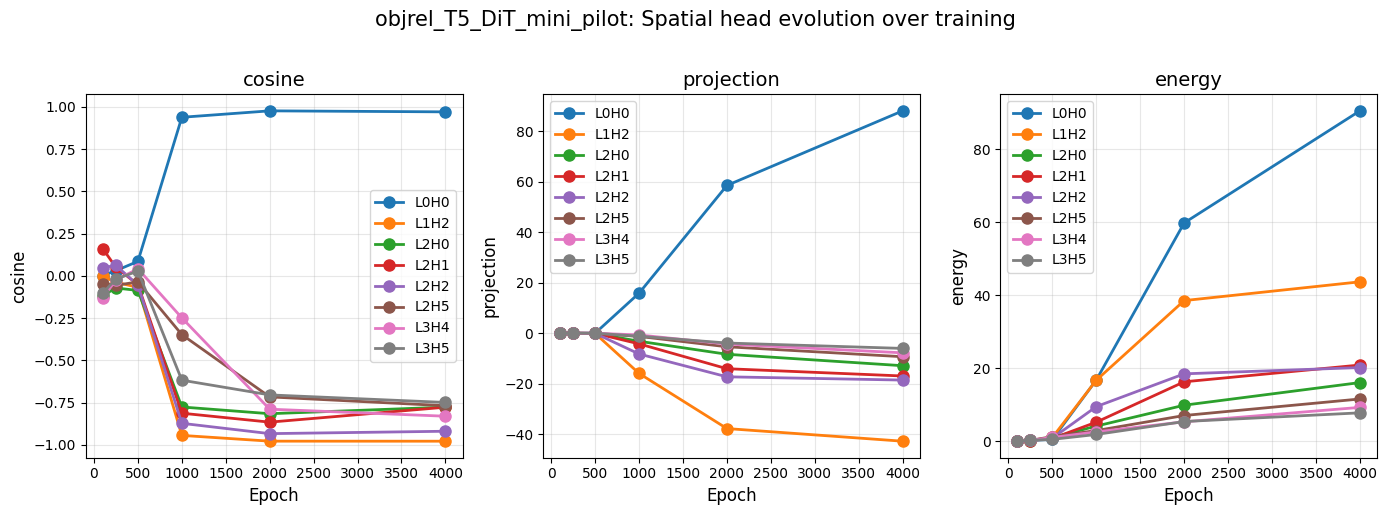

In [27]:
# Plot evolution of top spatial heads (auto-pick from final checkpoint |cosine| > 0.7)
final_ckpt = evolution_df[evolution_df["epoch"] == evolution_df["epoch"].max()]
top_heads = []
for _, row in final_ckpt.iterrows():
    if abs(row["cosine"]) > 0.7:
        top_heads.append((int(row["layer_idx"]), int(row["head_idx"])))
if not top_heads:
    top_heads = [(0, 0), (1, 2), (2, 3)]
print(f"Plotting evolution for: {top_heads}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["cosine", "projection", "energy"]):
    for layer_idx, head_idx in top_heads:
        subset = evolution_df[(evolution_df["layer_idx"] == layer_idx) & (evolution_df["head_idx"] == head_idx)]
        ax.plot(subset["epoch"], subset[metric], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=8)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle(f"{model_run_name}: Spatial head evolution over training", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

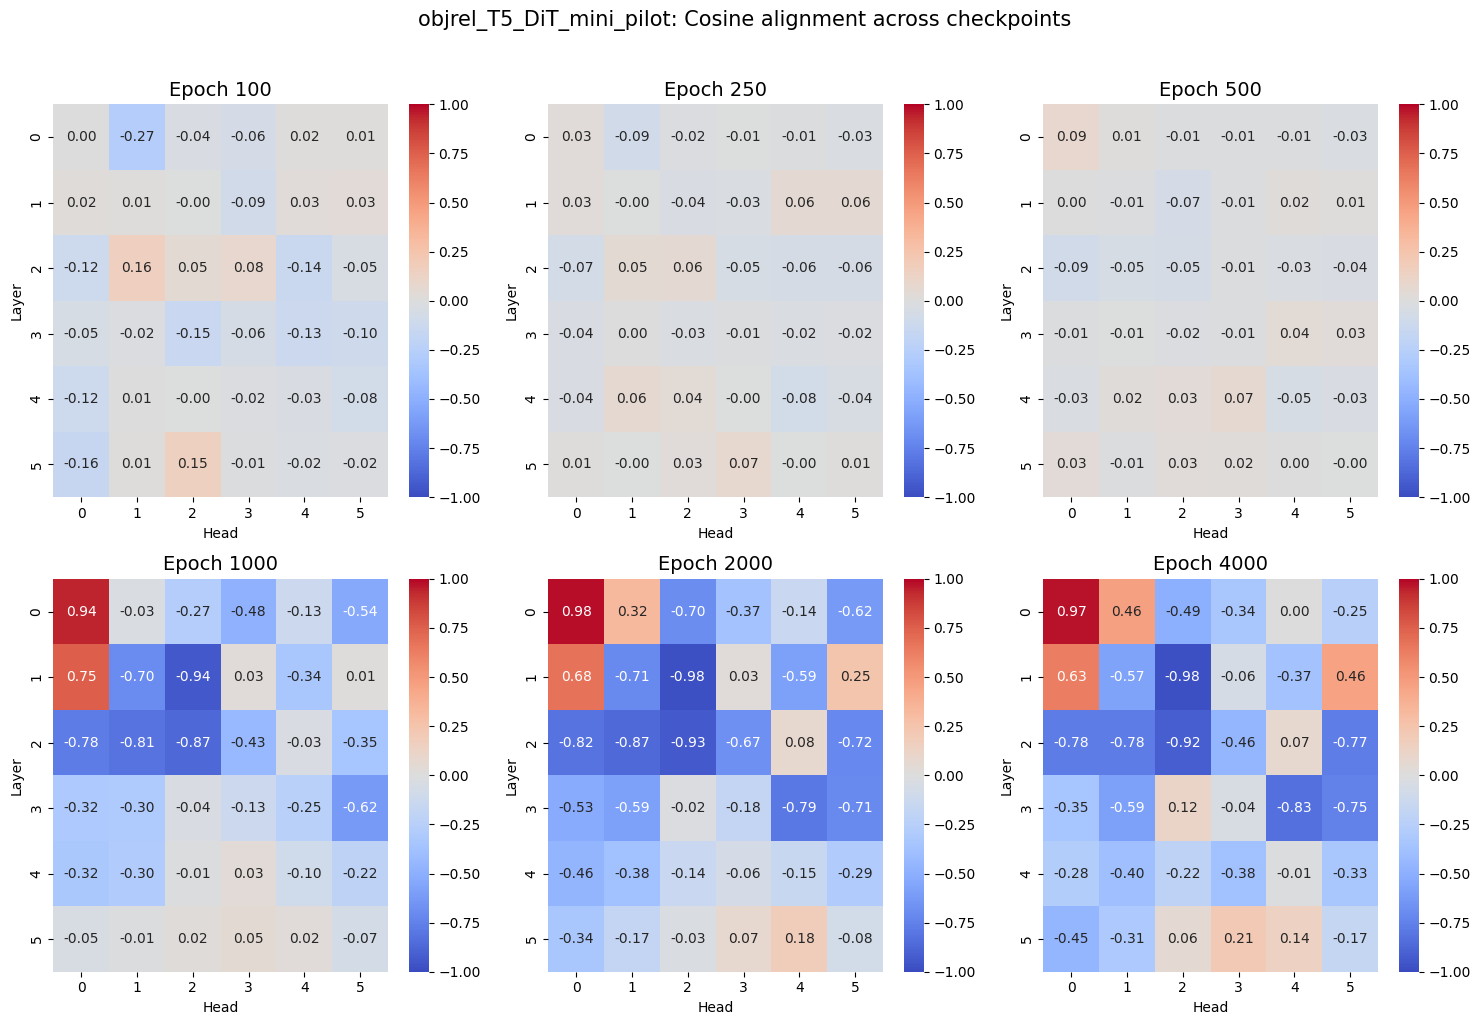

In [28]:
# Cosine alignment heatmaps across all checkpoints
epochs = sorted(evolution_df["epoch"].unique())
n_ckpts = len(epochs)
ncols = 3
nrows = (n_ckpts + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)

for idx, epoch in enumerate(epochs):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df[evolution_df["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")

for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)

plt.suptitle(f"{model_run_name}: Cosine alignment across checkpoints", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### Heatmap comparison: early vs late checkpoint

Cosine alignment heatmaps at epoch 100 vs epoch 4000.

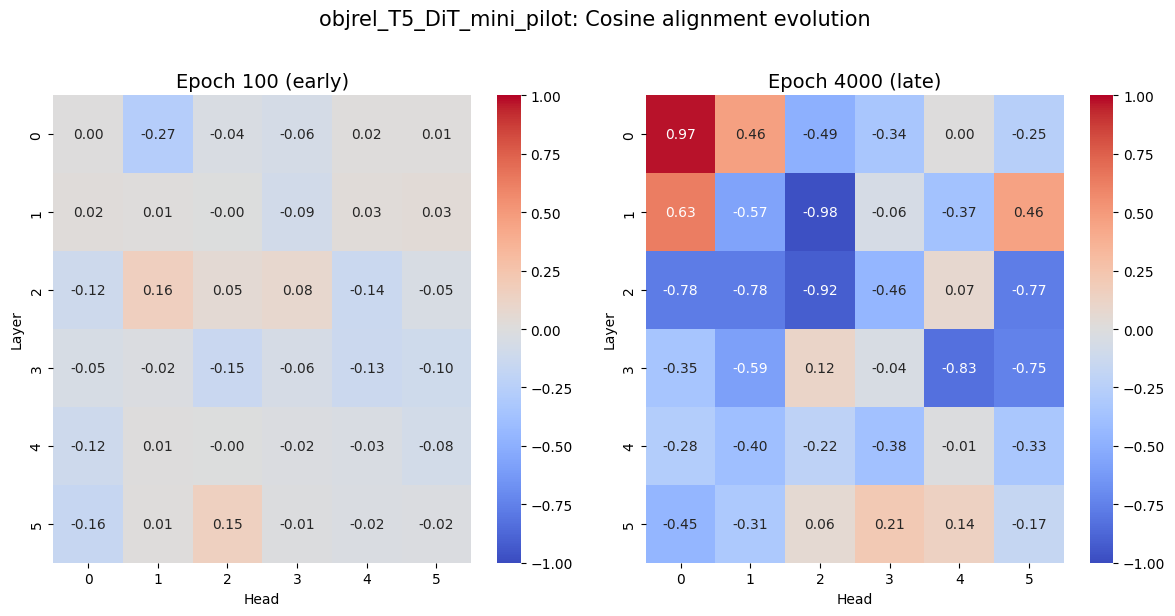

In [29]:
# Early vs late checkpoint — cosine alignment heatmaps
early = evolution_df[evolution_df["epoch"] == 100]
late = evolution_df[evolution_df["epoch"] == 4000]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, df_sub, title in [
    (axes[0], early, "Epoch 100 (early)"),
    (axes[1], late, "Epoch 4000 (late)"),
]:
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
plt.suptitle(f"{model_run_name}: Cosine alignment evolution", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### Fixed relation direction (from final checkpoint)

Same cosine alignment, but using the spatial_relationship effect vectors from the **final checkpoint only** — the relation direction is fixed; only the attn2 weights change across checkpoints.

Total R² (all features): 0.6200


Fixed direction: 100%|██████████| 6/6 [00:02<00:00,  2.80it/s]


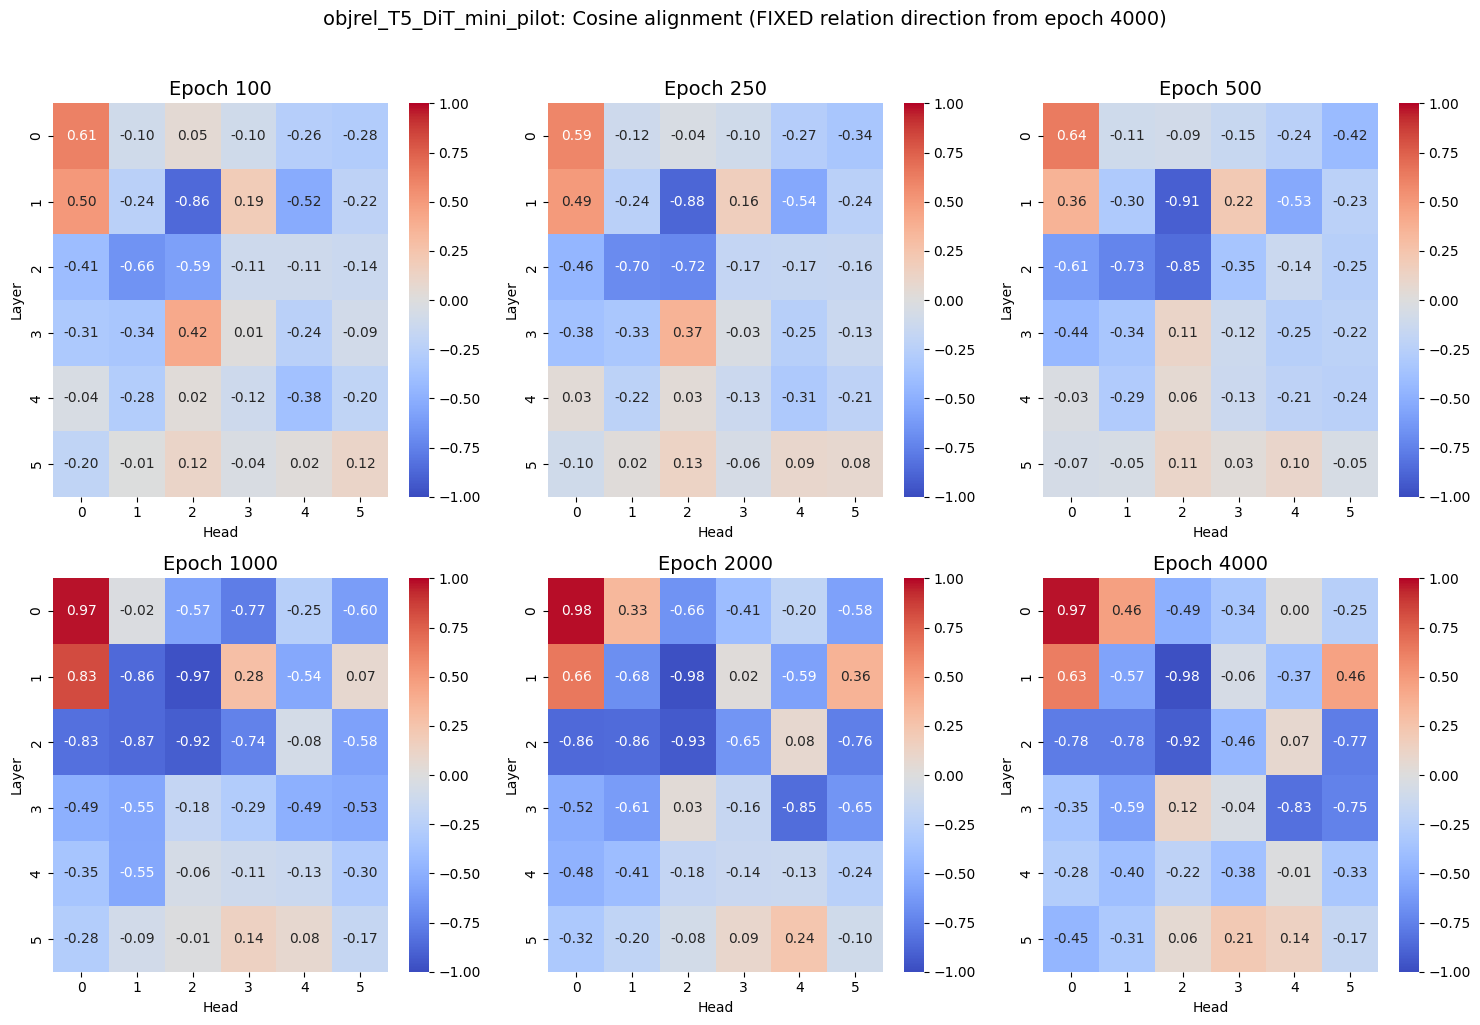

14017

In [30]:
# 1. Get fixed relation direction from final checkpoint
ckpt_final = "epoch_4000_step_160000.pth"
ckpt = torch.load(join(ckptdir, ckpt_final), map_location="cpu", weights_only=False)
pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
del ckpt
gc.collect()

# Project embeddings, variance partition → fixed effect_vecs
df_tmp = prompt_scene_info_all_df.copy()
df_tmp["color1shape1"] = df_tmp["color1"] + "_" + df_tmp["shape1"]
df_tmp["color2shape2"] = df_tmp["color2"] + "_" + df_tmp["shape2"]
wordvec_obj2_col = []
for row in prompt_scene_info_all_df.itertuples():
    tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
    tokens = [pipeline.tokenizer.decode([t]) for t in tokenized['input_ids'][0]]
    shape2_idx = find_shape_index(tokens, row.shape2)
    cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
    wordvec_obj2_col.append(cap_embeds[0, shape2_idx, :])
wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
with torch.no_grad():
    wordvec_obj2_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
_, _, effect_vecs_fixed, levels_map_fixed, _ = variance_partition_with_effects(
    wordvec_obj2_proj.float().cpu().numpy(),
    {"spatial_relationship": df_tmp["spatial_relationship"], "shape1": df_tmp["shape1"], "color2shape2": df_tmp["color2shape2"]},
    metric="euclidean", n_perm=n_perm_evolution, verbose=False)

# 2. For each checkpoint: load attn2, compute alignment with FIXED effect_vecs
evolution_records_fixed = []
for ckpt_name in tqdm(ckpt_files, desc="Fixed direction"):
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    epoch = int(ckpt_name.split("_")[1])
    
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_fixed["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_fixed["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    head_synopsis = pd.concat(align_df_list).groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["epoch"] = epoch
    head_synopsis["checkpoint"] = ckpt_name
    evolution_records_fixed.append(head_synopsis.reset_index())

evolution_df_fixed = pd.concat(evolution_records_fixed, ignore_index=True)

# 3. Plot heatmaps (same layout as above)
epochs_f = sorted(evolution_df_fixed["epoch"].unique())
n_ckpts = len(epochs_f)
ncols, nrows = 3, (n_ckpts + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)
for idx, epoch in enumerate(epochs_f):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df_fixed[evolution_df_fixed["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)
plt.suptitle(f"{model_run_name}: Cosine alignment (FIXED relation direction from epoch 4000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Reload final checkpoint for downstream cells
ckpt = torch.load(join(ckptdir, ckpt_final), map_location="cpu", weights_only=False)
pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
del ckpt
gc.collect()

### Relation head emergence (epochs 500–1000)

Fine-grained view using checkpoints 500, 600, 700, 750, 800, 900, 1000 — where the spatial relation head becomes identifiable.

In [31]:
# Run evolution for emergence checkpoints only (500–1000)
# Uses same config as main loop (layer_num, head_num, etc. from cell 32)
transformer_config = PixArt_model_configs[config.model] if config is not None else PixArt_model_configs["PixArt_mini_2"]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num

evo_em_records, var_part_em, q_norms_em = [], [], []
for ckpt_name in tqdm(ckpt_files_emergence, desc="Emergence checkpoints"):
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    epoch = int(ckpt_name.split("_")[1])
    df = prompt_scene_info_all_df.copy()
    df["color1shape1"] = df["color1"] + "_" + df["shape1"]
    df["color2shape2"] = df["color2"] + "_" + df["shape2"]
    
    wordvec_obj2_col = []
    for row in prompt_scene_info_all_df.itertuples():
        tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
        tokens = [pipeline.tokenizer.decode([t]) for t in tokenized['input_ids'][0]]
        shape2_idx = find_shape_index(tokens, row.shape2)
        cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
        wordvec_obj2_col.append(cap_embeds[0, shape2_idx, :])
    wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
    with torch.no_grad():
        wordvec_obj2_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
    
    var_part_ckpt, _, effect_vecs_ckpt, levels_map_ckpt, _ = variance_partition_with_effects(
        wordvec_obj2_proj.float().cpu().numpy(),
        {"spatial_relationship": df["spatial_relationship"], "shape1": df["shape1"], "color2shape2": df["color2shape2"]},
        metric="euclidean", n_perm=n_perm_evolution, verbose=False)
    var_part_ckpt = var_part_ckpt.copy()
    var_part_ckpt["epoch"] = epoch
    var_part_em.append(var_part_ckpt)
    
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_ckpt["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_ckpt["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    head_synopsis = pd.concat(align_df_list).groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["epoch"] = epoch
    head_synopsis["checkpoint"] = ckpt_name
    evo_em_records.append(head_synopsis.reset_index())
    
    for layer_idx in range(layer_num):
        q_w = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q.weight.float()
        q_heads = q_w.view(head_num, head_dim, -1)
        for head_idx in range(head_num):
            q_norms_em.append({"epoch": epoch, "layer_idx": layer_idx, "head_idx": head_idx, "q_norm": q_heads[head_idx].norm().item()})

evolution_df_em = pd.concat(evo_em_records, ignore_index=True)
var_part_df_em = pd.concat(var_part_em, ignore_index=True)
q_norms_df_em = pd.DataFrame(q_norms_em)
print(f"Emergence data: {len(evolution_df_em)} alignment rows, {len(var_part_df_em)} var partition rows")

Emergence checkpoints:   0%|          | 0/7 [00:00<?, ?it/s]

Emergence checkpoints:  14%|█▍        | 1/7 [00:00<00:02,  2.71it/s]

Total R² (all features): 0.9828


Emergence checkpoints:  29%|██▊       | 2/7 [00:01<00:02,  1.70it/s]

Total R² (all features): 0.9753


...

Total R² (all features): 0.9510


Emergence checkpoints:  86%|████████▌ | 6/7 [00:03<00:00,  1.75it/s]

Total R² (all features): 0.9346


Emergence checkpoints: 100%|██████████| 7/7 [00:03<00:00,  1.81it/s]

Total R² (all features): 0.9164
Emergence data: 252 alignment rows, 21 var partition rows


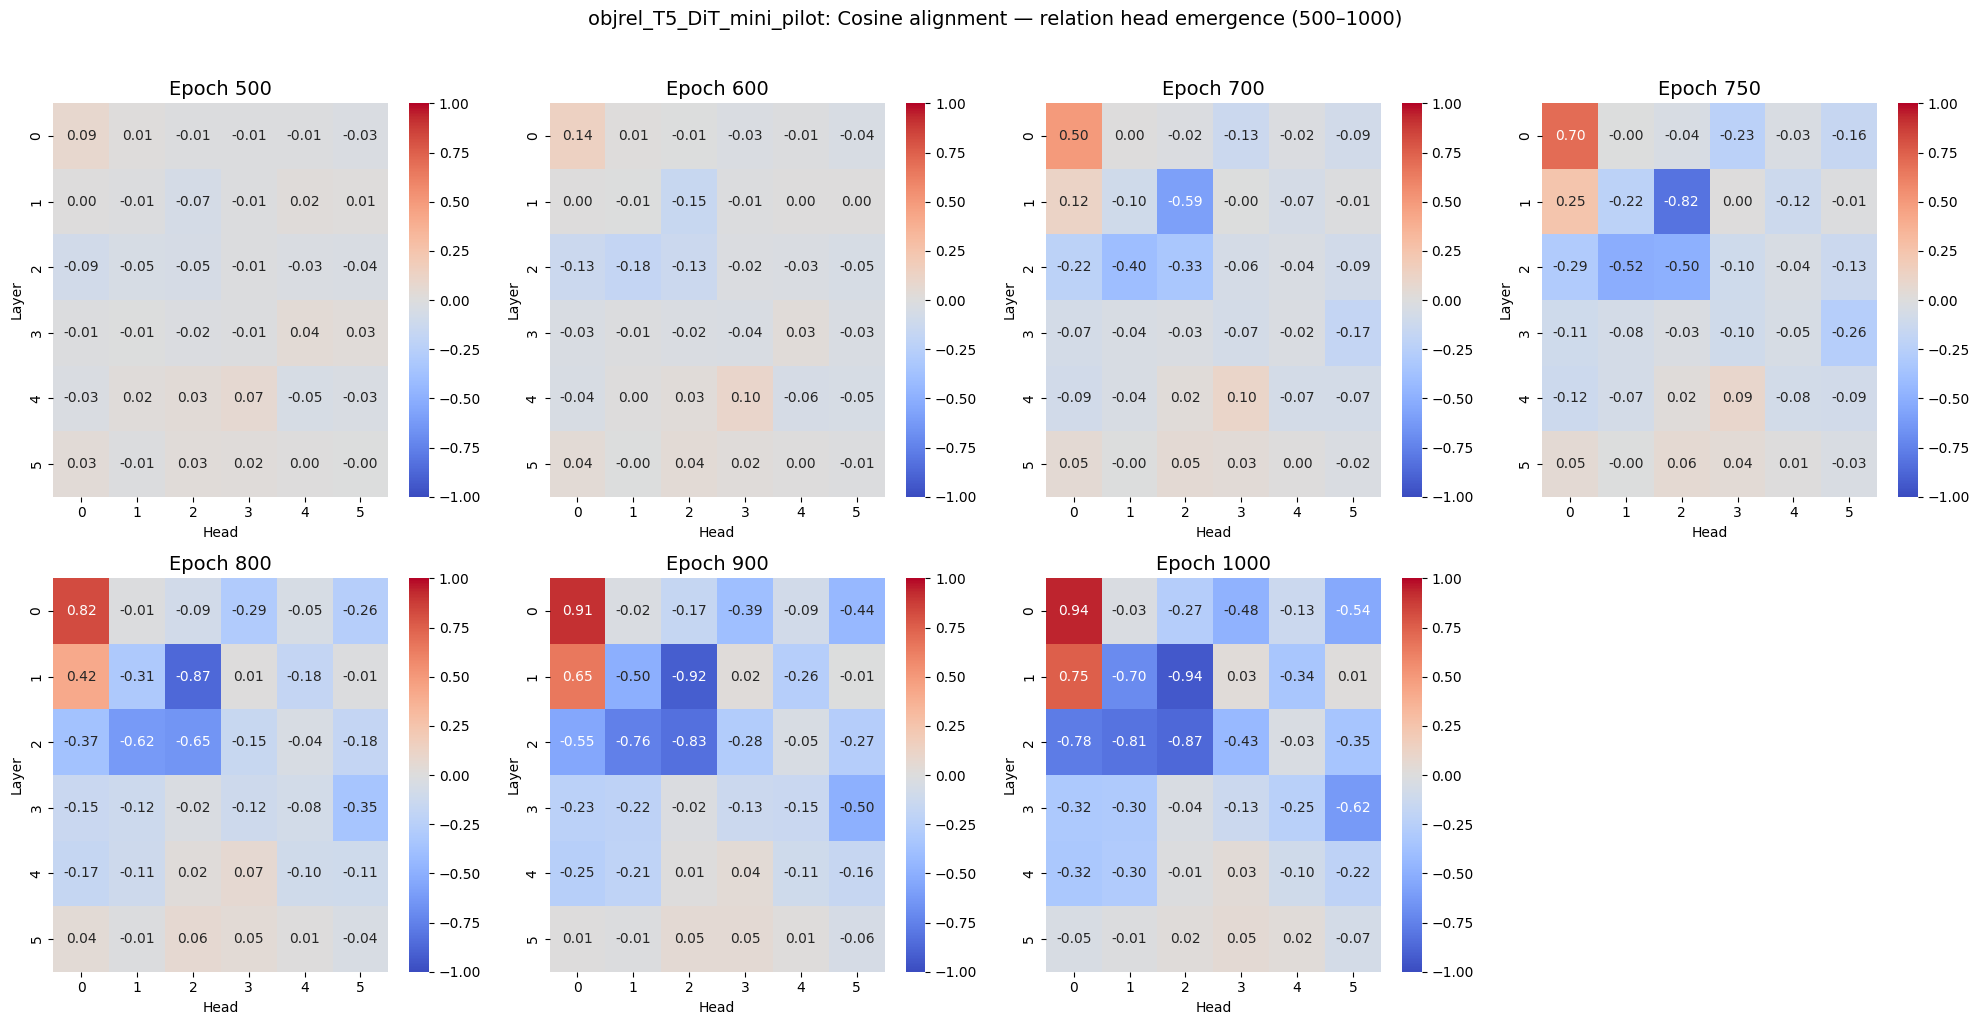

In [32]:
# Cosine alignment heatmaps: 500–1000 (relation head emergence)
epochs_em = sorted(evolution_df_em["epoch"].unique())
n_ckpts = len(epochs_em)
ncols = 4
nrows = (n_ckpts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)
for idx, epoch in enumerate(epochs_em):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df_em[evolution_df_em["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)
plt.suptitle(f"{model_run_name}: Cosine alignment — relation head emergence (500–1000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

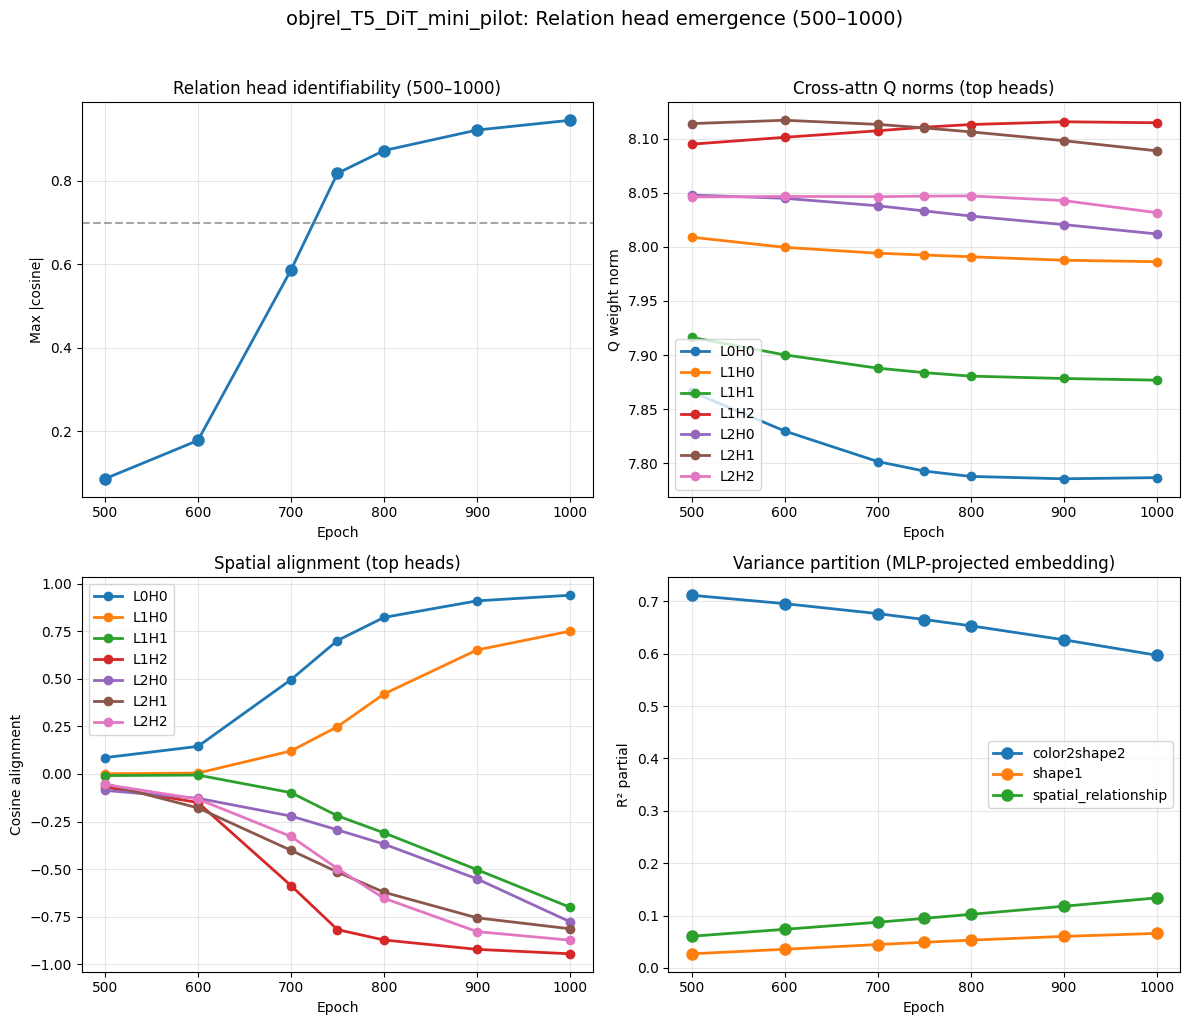

In [33]:
# Emergence: identifiability, projection norms, variance partition
top_em = []
for _, row in evolution_df_em[evolution_df_em["epoch"] == evolution_df_em["epoch"].max()].iterrows():
    if abs(row["cosine"]) > 0.7:
        top_em.append((int(row["layer_idx"]), int(row["head_idx"])))
if not top_em:
    top_em = [(0, 0), (1, 2), (2, 3)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Max |cosine| and gap
id_em = []
for epoch in sorted(evolution_df_em["epoch"].unique()):
    sub = evolution_df_em[evolution_df_em["epoch"] == epoch]
    abs_cos = sub["cosine"].abs()
    max_idx = abs_cos.idxmax()
    row = sub.loc[max_idx]
    top_layer, top_head = int(row["layer_idx"]), int(row["head_idx"])
    mean_other = sub[(sub["layer_idx"] != top_layer) | (sub["head_idx"] != top_head)]["cosine"].abs().mean()
    id_em.append({"epoch": epoch, "max_abs_cosine": abs(row["cosine"]), "gap": abs(row["cosine"]) - mean_other})
id_em = pd.DataFrame(id_em)
axes[0, 0].plot(id_em["epoch"], id_em["max_abs_cosine"], "o-", linewidth=2, markersize=8)
axes[0, 0].axhline(0.7, color="gray", linestyle="--", alpha=0.7)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Max |cosine|")
axes[0, 0].set_title("Relation head identifiability (500–1000)")
axes[0, 0].grid(True, alpha=0.3)

# (b) Q norms for top heads
for layer_idx, head_idx in top_em:
    sub = q_norms_df_em[(q_norms_df_em["layer_idx"] == layer_idx) & (q_norms_df_em["head_idx"] == head_idx)]
    axes[0, 1].plot(sub["epoch"], sub["q_norm"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Q weight norm")
axes[0, 1].set_title("Cross-attn Q norms (top heads)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# (c) Cosine for top heads
for layer_idx, head_idx in top_em:
    sub = evolution_df_em[(evolution_df_em["layer_idx"] == layer_idx) & (evolution_df_em["head_idx"] == head_idx)]
    axes[1, 0].plot(sub["epoch"], sub["cosine"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Cosine alignment")
axes[1, 0].set_title("Spatial alignment (top heads)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# (d) Variance partition (R² partial)
vp_em = var_part_df_em.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
for col in vp_em.columns:
    axes[1, 1].plot(vp_em.index, vp_em[col], "o-", label=col, linewidth=2, markersize=8)
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("R² partial")
axes[1, 1].set_title("Variance partition (MLP-projected embedding)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"{model_run_name}: Relation head emergence (500–1000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

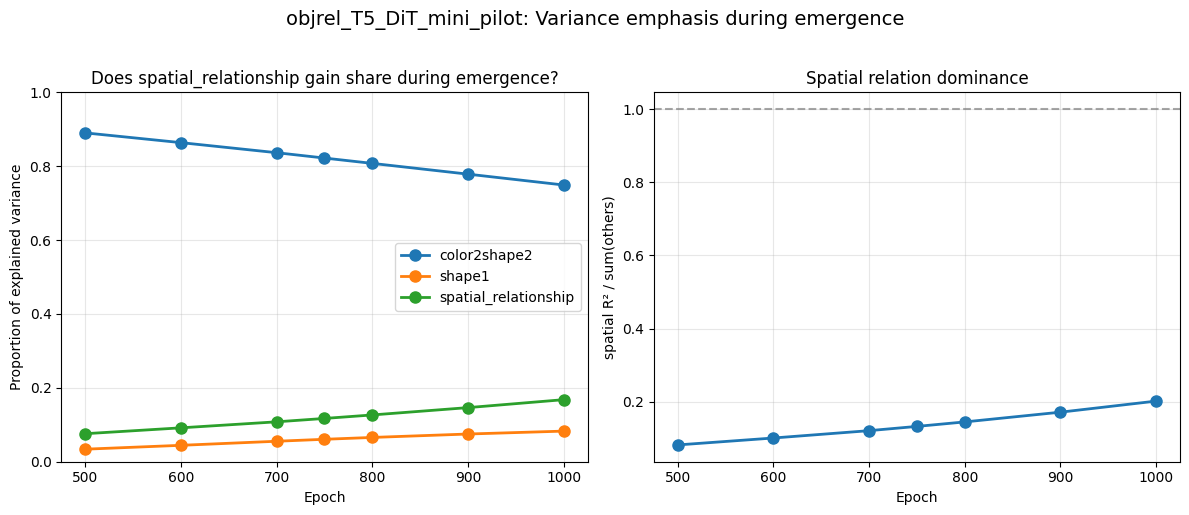

In [34]:
# Emergence: variance proportion and spatial dominance
vp_em = var_part_df_em.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
vp_prop_em = vp_em.div(vp_em.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for col in vp_prop_em.columns:
    axes[0].plot(vp_prop_em.index, vp_prop_em[col], "o-", label=col, linewidth=2, markersize=8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Proportion of explained variance")
axes[0].set_title("Does spatial_relationship gain share during emergence?")
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

if "spatial_relationship" in vp_em.columns:
    others = [c for c in vp_em.columns if c != "spatial_relationship"]
    ratio_em = vp_em["spatial_relationship"] / (vp_em[others].sum(axis=1) + 1e-10)
    axes[1].plot(vp_em.index, ratio_em, "o-", color="C0", linewidth=2, markersize=8)
    axes[1].axhline(1, color="gray", linestyle="--", alpha=0.7)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("spatial R² / sum(others)")
    axes[1].set_title("Spatial relation dominance")
    axes[1].grid(True, alpha=0.3)
plt.suptitle(f"{model_run_name}: Variance emphasis during emergence", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Identifiability and variance partition (evolution analysis)

The cells below analyze head identifiability, projection norms, and variance partition over training — evolution/alignment analysis, separate from the ablation experiments above.

### Functional characterization + validation (standalone fallback)

This version is runnable even if the causal-verification cell was not run first. If `trace_pair_summary_df` is missing, it will bootstrap a small pair-ablation sweep from the top-ranked trajectory candidates and then continue with functional characterization and held-out validation.


In [52]:
# Functional characterization (Method E) + held-out/generalization validation
# Standalone version: if causal verification has not been run, bootstrap it here from top-ranked candidates.
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

from utils.downstream_head_tracing import run_pair_ablation_grid, summarize_functional_effects

TRACE_VALIDATION_TOP_N = globals().get("TRACE_VALIDATION_TOP_N", 2)
TRACE_VALIDATION_N_IMAGES = globals().get("TRACE_VALIDATION_N_IMAGES", 1)
TRACE_VALIDATION_N_STEPS = globals().get("TRACE_VALIDATION_N_STEPS", max(8, min(TRACE_N_STEPS, 10)))
TRACE_VALIDATION_GUIDANCE_SCALE = globals().get("TRACE_VALIDATION_GUIDANCE_SCALE", TRACE_GUIDANCE_SCALE)
TRACE_GENERALIZATION_MAX_PROMPTS = globals().get("TRACE_GENERALIZATION_MAX_PROMPTS", 16)
TRACE_VALIDATION_CHECKPOINTS = globals().get(
    "TRACE_VALIDATION_CHECKPOINTS",
    [TRACE_DEV_CHECKPOINTS[-1]] if len(TRACE_DEV_CHECKPOINTS) > 0 else ckpt_files_ablation[-1:],
)
TRACE_FUNCTIONAL_FALLBACK_TOP_N = globals().get(
    "TRACE_FUNCTIONAL_FALLBACK_TOP_N",
    max(TRACE_VALIDATION_TOP_N, 2),
)
TRACE_FUNCTIONAL_DEV_CHECKPOINTS = globals().get(
    "TRACE_FUNCTIONAL_DEV_CHECKPOINTS",
    [TRACE_DEV_CHECKPOINTS[-1]] if len(TRACE_DEV_CHECKPOINTS) > 0 else TRACE_DEV_CHECKPOINTS,
)
TRACE_FUNCTIONAL_MAX_PROMPTS = globals().get("TRACE_FUNCTIONAL_MAX_PROMPTS", 12)

trace_pair_summary_df_local = None
if "trace_pair_summary_df" in dir() and trace_pair_summary_df is not None and not trace_pair_summary_df.empty:
    trace_pair_summary_df_local = trace_pair_summary_df.copy()
else:
    if "trace_candidate_rank_df" not in dir() or trace_candidate_rank_df is None or trace_candidate_rank_df.empty:
        raise RuntimeError("Run candidate discovery first so this standalone cell can choose fallback candidate heads.")
    fallback_candidate_heads = [
        (int(row.layer_idx), int(row.head_idx))
        for row in trace_candidate_rank_df.head(TRACE_FUNCTIONAL_FALLBACK_TOP_N).itertuples()
    ]
    trace_functional_prompts = prompts_ablation[:TRACE_FUNCTIONAL_MAX_PROMPTS]
    trace_functional_scene_infos = scene_infos_ablation[:TRACE_FUNCTIONAL_MAX_PROMPTS]
    print("No prior verification results found; running fallback pair ablations for functional characterization.")
    print("Fallback candidate heads:", fallback_candidate_heads)
    print(f"Quick fallback config: {len(TRACE_FUNCTIONAL_DEV_CHECKPOINTS)} checkpoint(s), {len(trace_functional_prompts)} prompt(s), {globals().get('TRACE_PAIR_N_IMAGES', min(TRACE_N_IMAGES_PER_PROMPT, 2))} image(s)/prompt")
    trace_pair_summary_df_local, trace_pair_eval_df_local = run_pair_ablation_grid(
        pipeline=pipeline,
        ckptdir=ckptdir,
        ckpt_list=TRACE_FUNCTIONAL_DEV_CHECKPOINTS,
        prompts=trace_functional_prompts,
        scene_infos=trace_functional_scene_infos,
        embedding_cache=embedding_cache_ablation,
        source_head=SOURCE_REL_HEAD,
        candidate_heads=fallback_candidate_heads,
        state_dict_convert=state_dict_convert,
        device=device,
        weight_dtype=compute_dtype,
        num_images=globals().get("TRACE_PAIR_N_IMAGES", min(TRACE_N_IMAGES_PER_PROMPT, 2)),
        num_inference_steps=globals().get("TRACE_PAIR_N_STEPS", max(8, min(TRACE_N_STEPS, 10))),
        guidance_scale=globals().get("TRACE_PAIR_GUIDANCE_SCALE", TRACE_GUIDANCE_SCALE),
        generator_seed=42,
        metric_cols=[
            "spatial_relationship", "spatial_relationship_loose", "overall",
            "unique_binding", "exist_binding",
        ],
        show_prompt_progress=False,
        progress_mode="print",
    )
    trace_pair_summary_df = trace_pair_summary_df_local.copy()
    trace_pair_eval_df = trace_pair_eval_df_local.copy()

print("Summarizing functional roles...")
trace_role_df = summarize_functional_effects(
    trace_pair_summary_df_local,
    show_progress=False,
)
display(trace_role_df)

if not trace_role_df.empty:
    top_role_df = trace_role_df.head(min(TRACE_VALIDATION_TOP_N, len(trace_role_df))).copy()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].bar(top_role_df["candidate_head"], top_role_df["binding_reader_score"], label="binding score")
    axes[0].bar(top_role_df["candidate_head"], top_role_df["location_reader_score"], alpha=0.6, label="location score")
    axes[0].set_title("Role scores")
    axes[0].set_ylabel("Mean delta score")
    axes[0].grid(True, axis="y", alpha=0.3)
    axes[0].legend(fontsize=8)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha="right")

    delta_cols = [c for c in top_role_df.columns if c.startswith("candidate_only_") and c.endswith("_delta_mean")]
    plot_df = top_role_df[["candidate_head", *delta_cols]].set_index("candidate_head").T
    plot_df.plot(kind="bar", ax=axes[1], width=0.8)
    axes[1].set_title("Candidate-only functional deltas")
    axes[1].set_ylabel("Baseline - ablated")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].legend(fontsize=7)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def build_generalization_prompt_subset(prompt_scene_df, embedding_cache, max_prompts=None):
    prompts = []
    scene_infos = []
    for r in prompt_scene_df.itertuples():
        prompt = r.prompt
        if not any(k != "" and k.endswith(f"::{prompt}") for k in embedding_cache):
            continue
        prompts.append(prompt)
        scene_infos.append(
            {
                "color1": r.color1,
                "shape1": r.shape1,
                "color2": r.color2,
                "shape2": r.shape2,
                "spatial_relationship": r.spatial_relationship,
            }
        )
        if max_prompts is not None and len(prompts) >= max_prompts:
            break
    return prompts, scene_infos


validation_candidate_heads = []
for row in trace_role_df.head(min(TRACE_VALIDATION_TOP_N, len(trace_role_df))).itertuples():
    lay = int(row.candidate_head.split("H")[0][1:])
    hd = int(row.candidate_head.split("H")[1])
    validation_candidate_heads.append((lay, hd))
print("Validation candidate heads:", validation_candidate_heads)

trace_generalization_prompts, trace_generalization_scene_infos = build_generalization_prompt_subset(
    prompt_scene_info_all_df,
    embedding_cache_ablation,
    max_prompts=TRACE_GENERALIZATION_MAX_PROMPTS,
)
print(f"Generalization validation prompts: {len(trace_generalization_prompts)}")

print(f"Quick validation config: {len(TRACE_VALIDATION_CHECKPOINTS)} checkpoint(s), {len(trace_generalization_prompts)} prompt(s), {TRACE_VALIDATION_N_IMAGES} image(s)/prompt")
trace_pair_validation_df, _ = run_pair_ablation_grid(
    pipeline=pipeline,
    ckptdir=ckptdir,
    ckpt_list=TRACE_VALIDATION_CHECKPOINTS,
    prompts=trace_generalization_prompts,
    scene_infos=trace_generalization_scene_infos,
    embedding_cache=embedding_cache_ablation,
    source_head=SOURCE_REL_HEAD,
    candidate_heads=validation_candidate_heads,
    state_dict_convert=state_dict_convert,
    device=device,
    weight_dtype=compute_dtype,
    num_images=TRACE_VALIDATION_N_IMAGES,
    num_inference_steps=TRACE_VALIDATION_N_STEPS,
    guidance_scale=TRACE_VALIDATION_GUIDANCE_SCALE,
    generator_seed=42,
    metric_cols=[
        "spatial_relationship", "spatial_relationship_loose", "overall",
        "unique_binding", "exist_binding",
    ],
    show_prompt_progress=False,
    progress_mode="print",
)

validation_show_cols = [
    "epoch", "condition_label", "candidate_head", "spatial_relationship",
    "unique_binding", "exist_binding", "overall",
    "spatial_relationship_delta_from_baseline", "unique_binding_delta_from_baseline",
]
display(trace_pair_validation_df[validation_show_cols])


No prior verification results found; running fallback pair ablations for functional characterization.
Fallback candidate heads: [(3, 5), (2, 2), (2, 1)]



Pair ablations:   0%|          | 5/1980 [01:45<11:32:37, 21.04s/prompt, condition=baseline, epoch=500]




KeyboardInterrupt: 

### Alternate candidate discovery: Method A (OV-QK composition)

This is a cheap structural screen that does not require image generation. It scores later cross-attention heads by how strongly their `Q` and `K` weights can read the source relation head's `OV` write-map. Treat it as a screening heuristic to complement the training-trajectory correlation method, not as causal evidence.


In [54]:
# Candidate discovery via OV-QK composition screening (Method A)
import gc
import pandas as pd
import torch
import matplotlib.pyplot as plt
from os.path import join, basename
from IPython.display import display

from utils.downstream_head_tracing import screen_downstream_candidates_by_ov_qk

TRACE_METHOD_A_CHECKPOINTS = globals().get(
    "TRACE_METHOD_A_CHECKPOINTS",
    [TRACE_DEV_CHECKPOINTS[-1]] if "TRACE_DEV_CHECKPOINTS" in dir() and len(TRACE_DEV_CHECKPOINTS) > 0 else ([ckpt_files_ablation[-1]] if "ckpt_files_ablation" in dir() and len(ckpt_files_ablation) > 0 else []),
)
TRACE_METHOD_A_CANDIDATE_LAYERS = globals().get(
    "TRACE_METHOD_A_CANDIDATE_LAYERS",
    globals().get("TRACE_CANDIDATE_LAYERS", "later_only"),
)
TRACE_METHOD_A_TOP_CANDIDATES = globals().get("TRACE_METHOD_A_TOP_CANDIDATES", 10)
TRACE_METHOD_A_SHOW_CHECKPOINT_TABLE = globals().get("TRACE_METHOD_A_SHOW_CHECKPOINT_TABLE", True)

if len(TRACE_METHOD_A_CHECKPOINTS) == 0:
    raise RuntimeError("No checkpoints available for Method A OV-QK screening.")

trace_method_a_records = []
for ckpt_idx, ckpt_name in enumerate(TRACE_METHOD_A_CHECKPOINTS, start=1):
    epoch = int(basename(ckpt_name).split("_")[1])
    print(f"[Method A] checkpoint {ckpt_idx}/{len(TRACE_METHOD_A_CHECKPOINTS)} | epoch {epoch}", flush=True)

    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt["state_dict_ema"]))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()

    df_ckpt = screen_downstream_candidates_by_ov_qk(
        pipeline.transformer,
        SOURCE_REL_HEAD,
        candidate_layers=TRACE_METHOD_A_CANDIDATE_LAYERS,
        show_progress=False,
    )
    df_ckpt["epoch"] = epoch
    df_ckpt["checkpoint"] = basename(ckpt_name)
    trace_method_a_records.append(df_ckpt)

trace_method_a_df = pd.concat(trace_method_a_records, ignore_index=True)
trace_method_a_summary_df = (
    trace_method_a_df.groupby(["layer_idx", "head_idx", "head_label", "source_head"], as_index=False)
    .agg(
        ov_qk_composite_mean=("ov_qk_composite_score", "mean"),
        ov_qk_composite_max=("ov_qk_composite_score", "max"),
        ov_qk_frob_mean=("ov_qk_frob_norm", "mean"),
        ov_qk_spectral_mean=("ov_qk_spectral_norm", "mean"),
        q_read_mean=("q_read_score_norm", "mean"),
        k_source_mean=("k_source_score_norm", "mean"),
    )
    .sort_values(["ov_qk_composite_mean", "ov_qk_frob_mean", "q_read_mean"], ascending=[False, False, False])
    .reset_index(drop=True)
)
trace_method_a_table_df = trace_method_a_df[
    [
        "epoch", "head_label", "source_head",
        "ov_qk_composite_score", "ov_qk_frob_norm", "ov_qk_spectral_norm",
        "q_read_score_norm", "k_source_score_norm",
    ]
].sort_values(["epoch", "ov_qk_composite_score"], ascending=[True, False]).reset_index(drop=True)

print(f"Source relation head: L{SOURCE_REL_HEAD[0]}H{SOURCE_REL_HEAD[1]}")
print("Method A aggregated candidate ranking:")
display(trace_method_a_summary_df.head(TRACE_METHOD_A_TOP_CANDIDATES))
if TRACE_METHOD_A_SHOW_CHECKPOINT_TABLE:
    print("Method A per-checkpoint OV-QK table:")
    display(trace_method_a_table_df)

plot_candidates = trace_method_a_summary_df.head(min(3, len(trace_method_a_summary_df)))
if not plot_candidates.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for _, cand in plot_candidates.iterrows():
        sub = trace_method_a_df[
            (trace_method_a_df["layer_idx"] == int(cand["layer_idx"]))
            & (trace_method_a_df["head_idx"] == int(cand["head_idx"]))
        ].sort_values("epoch")
        axes[0].plot(sub["epoch"], sub["ov_qk_composite_score"], "o-", linewidth=2, label=cand["head_label"])
        axes[1].plot(sub["epoch"], sub["q_read_score_norm"], "o-", linewidth=2, label=cand["head_label"])
        axes[2].plot(sub["epoch"], sub["k_source_score_norm"], "o-", linewidth=2, label=cand["head_label"])

    axes[0].set_title("OV-QK composite score")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Score")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].set_title("Q read score")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Normalized score")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)

    axes[2].set_title("K source score")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Normalized score")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=8)

    plt.suptitle("Method A OV-QK candidate discovery", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


[Method A] checkpoint 1/9 | epoch 500


Pair ablations:   1%|          | 13/1980 [20:41<52:10:27, 95.49s/prompt, condition=baseline, epoch=500]


NameError: name '_resolve_cross_attn_transformer' is not defined

### 1. When does the relation head become identifiable?

Track max |cosine| and the gap between top head and others across epochs.

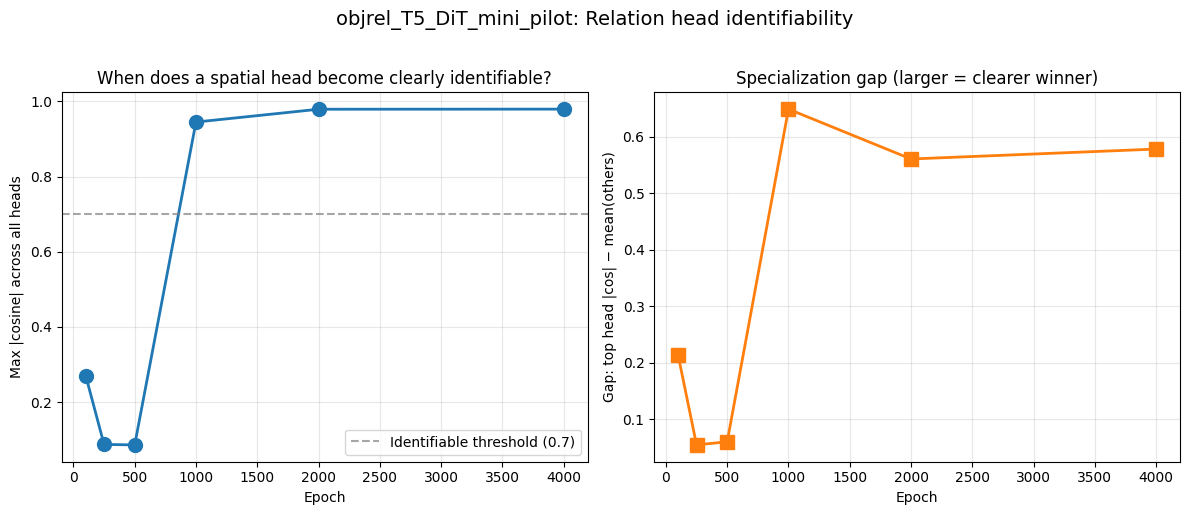

First epoch with max |cosine| ≥ 0.7: 1000


In [ ]:
# Per-epoch: max |cosine|, top head identity, and specialization gap
identifiability = []
for epoch in sorted(evolution_df["epoch"].unique()):
    sub = evolution_df[evolution_df["epoch"] == epoch]
    abs_cos = sub["cosine"].abs()
    max_idx = abs_cos.idxmax()
    row = sub.loc[max_idx]
    max_cos = row["cosine"]
    top_layer, top_head = int(row["layer_idx"]), int(row["head_idx"])
    mean_other = sub[(sub["layer_idx"] != top_layer) | (sub["head_idx"] != top_head)]["cosine"].abs().mean()
    gap = abs(max_cos) - mean_other
    identifiability.append({
        "epoch": epoch,
        "max_abs_cosine": abs(max_cos),
        "top_layer": top_layer, "top_head": top_head,
        "gap_vs_others": gap,
    })
id_df = pd.DataFrame(identifiability)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(id_df["epoch"], id_df["max_abs_cosine"], "o-", linewidth=2, markersize=10)
axes[0].axhline(0.7, color="gray", linestyle="--", alpha=0.7, label="Identifiable threshold (0.7)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Max |cosine| across all heads")
axes[0].set_title("When does a spatial head become clearly identifiable?")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(id_df["epoch"], id_df["gap_vs_others"], "s-", color="C1", linewidth=2, markersize=10)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Gap: top head |cos| − mean(others)")
axes[1].set_title("Specialization gap (larger = clearer winner)")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"{model_run_name}: Relation head identifiability", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Epoch when first clearly identifiable
first_id = id_df[id_df["max_abs_cosine"] >= 0.7]["epoch"].min()
print(f"First epoch with max |cosine| ≥ 0.7: {first_id}")

### 2. Projection norms and attention patterns over training

Q weight norms (cross-attention) and alignment metrics (cosine, projection) for key heads.

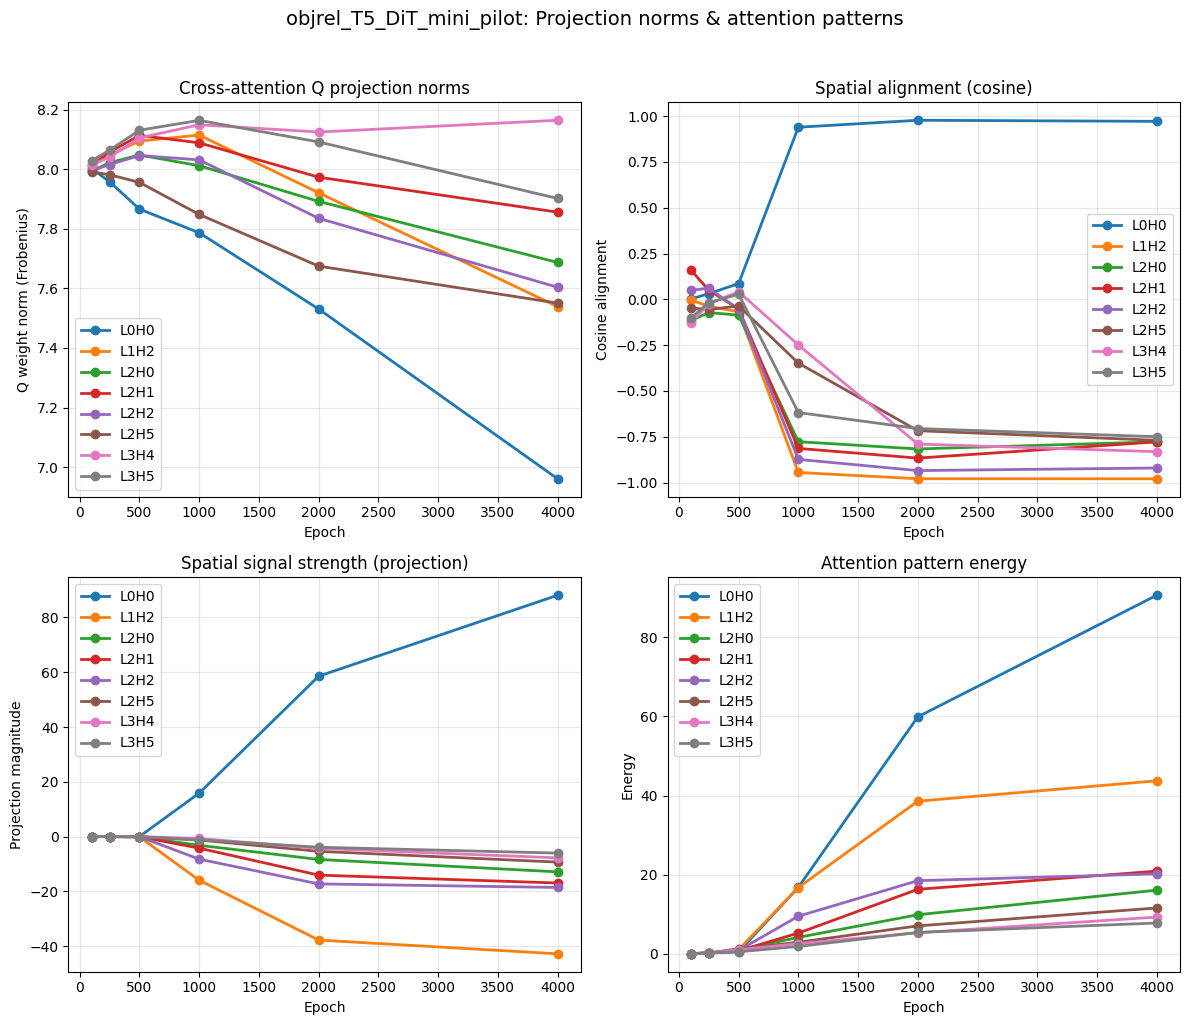

In [ ]:
# Top spatial heads from final checkpoint
top_heads = []
for _, row in evolution_df[evolution_df["epoch"] == evolution_df["epoch"].max()].iterrows():
    if abs(row["cosine"]) > 0.7:
        top_heads.append((int(row["layer_idx"]), int(row["head_idx"])))
if not top_heads:
    top_heads = [(0, 0), (1, 2), (2, 3)]

has_q_norms = len(q_norms_df) > 0 and "layer_idx" in q_norms_df.columns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Q weight norms for top heads (skip if empty)
ax = axes[0, 0]
if has_q_norms:
    for layer_idx, head_idx in top_heads:
        sub = q_norms_df[(q_norms_df["layer_idx"] == layer_idx) & (q_norms_df["head_idx"] == head_idx)]
        ax.plot(sub["epoch"], sub["q_norm"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
else:
    ax.text(0.5, 0.5, "Run evolution loop (cell 32)\nto populate Q norms", ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("Epoch")
ax.set_ylabel("Q weight norm (Frobenius)")
ax.set_title("Cross-attention Q projection norms")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Cosine alignment for top heads
ax = axes[0, 1]
for layer_idx, head_idx in top_heads:
    sub = evolution_df[(evolution_df["layer_idx"] == layer_idx) & (evolution_df["head_idx"] == head_idx)]
    ax.plot(sub["epoch"], sub["cosine"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cosine alignment")
ax.set_title("Spatial alignment (cosine)")
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Projection magnitude for top heads
ax = axes[1, 0]
for layer_idx, head_idx in top_heads:
    sub = evolution_df[(evolution_df["layer_idx"] == layer_idx) & (evolution_df["head_idx"] == head_idx)]
    ax.plot(sub["epoch"], sub["projection"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
ax.set_xlabel("Epoch")
ax.set_ylabel("Projection magnitude")
ax.set_title("Spatial signal strength (projection)")
ax.legend()
ax.grid(True, alpha=0.3)

# (d) Energy for top heads
ax = axes[1, 1]
for layer_idx, head_idx in top_heads:
    sub = evolution_df[(evolution_df["layer_idx"] == layer_idx) & (evolution_df["head_idx"] == head_idx)]
    ax.plot(sub["epoch"], sub["energy"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
ax.set_xlabel("Epoch")
ax.set_ylabel("Energy")
ax.set_title("Attention pattern energy")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f"{model_run_name}: Projection norms & attention patterns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Variance partition experiments: Does the MLP emphasize spatial relation over training?

**Hypothesis:** Through training, the caption_projection (MLP) learns to extract and emphasize the spatial relation signal, so the spatial_relationship component should gain a larger proportion of variance over time.

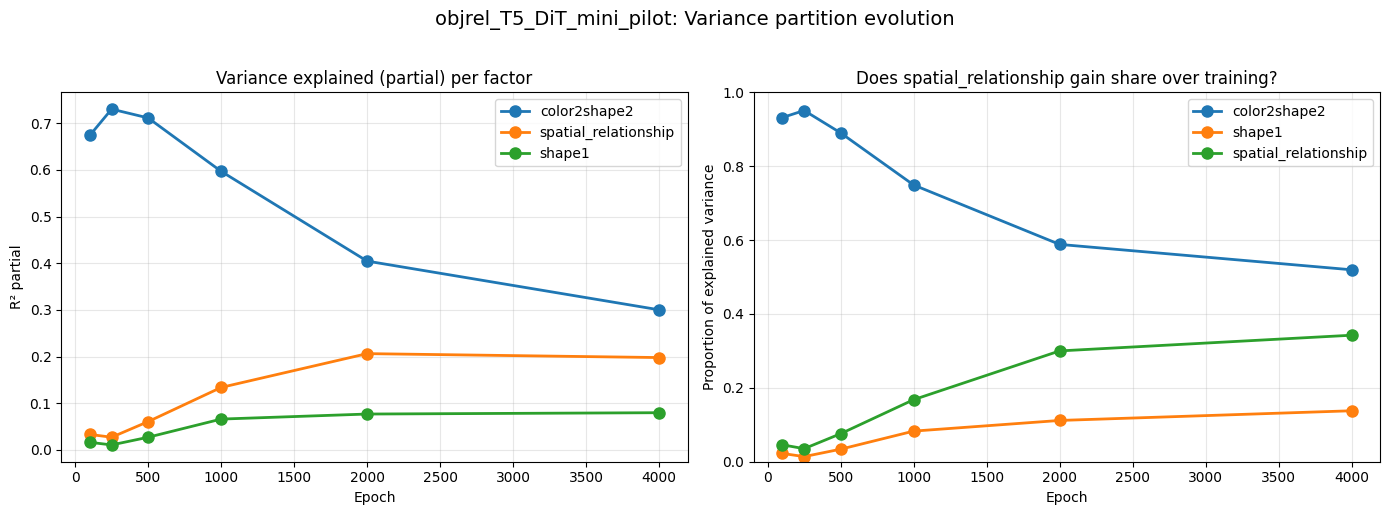

In [ ]:
# Exp 1: R² partial per factor over epochs (baseline)
if var_part_df_evolution.empty:
    print("Run evolution loop (cell 32) first.")
else:
    vp = var_part_df_evolution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # (a) Raw R² partial
    for feat in vp["feature"].unique():
        sub = vp[vp["feature"] == feat]
        axes[0].plot(sub["epoch"], sub["R2_partial"], "o-", label=feat, linewidth=2, markersize=8)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("R² partial")
    axes[0].set_title("Variance explained (partial) per factor")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # (b) Proportion of total explained variance (R² partial / sum of all R² partial per epoch)
    vp_pivot = vp.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
    vp_prop = vp_pivot.div(vp_pivot.sum(axis=1), axis=0)
    for col in vp_prop.columns:
        axes[1].plot(vp_prop.index, vp_prop[col], "o-", label=col, linewidth=2, markersize=8)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Proportion of explained variance")
    axes[1].set_title("Does spatial_relationship gain share over training?")
    axes[1].legend()
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f"{model_run_name}: Variance partition evolution", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

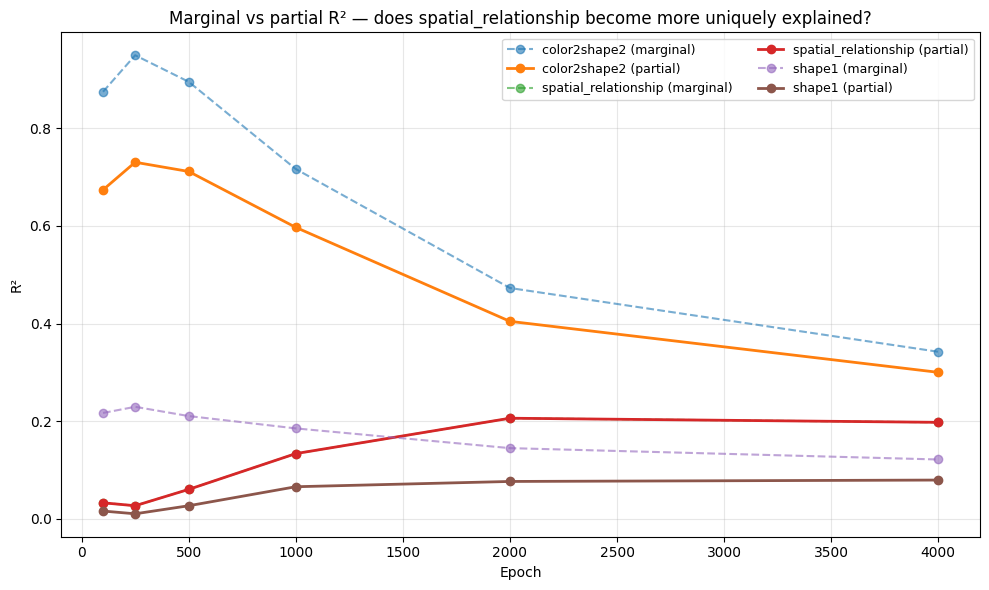

In [ ]:
# Exp 2: Marginal vs partial R² — disentanglement over training
# Marginal = variance explained by factor alone. Partial = unique variance after controlling for others.
# If partial increases while marginal stays similar, the MLP is better at isolating the spatial signal.
if var_part_df_evolution.empty:
    print("Run evolution loop (cell 32) first.")
else:
    vp = var_part_df_evolution
    fig, ax = plt.subplots(figsize=(10, 6))
    for feat in vp["feature"].unique():
        sub = vp[vp["feature"] == feat].sort_values("epoch")
        ax.plot(sub["epoch"], sub["R2_marginal"], "o--", alpha=0.6, label=f"{feat} (marginal)")
        ax.plot(sub["epoch"], sub["R2_partial"], "o-", linewidth=2, label=f"{feat} (partial)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("R²")
    ax.set_title("Marginal vs partial R² — does spatial_relationship become more uniquely explained?")
    ax.legend(ncol=2, fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

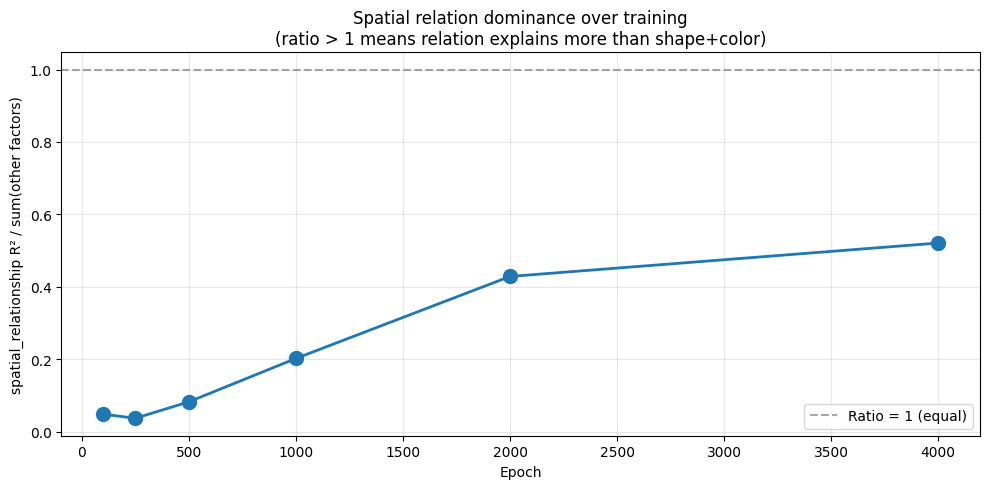

Spatial dominance ratio by epoch:
epoch
100     0.048047
250     0.036628
500     0.082066
1000    0.201866
2000    0.428470
4000    0.520801


In [ ]:
# Exp 3: Spatial relation dominance — ratio of spatial_relationship R² to other factors
# If this ratio increases over training, the MLP is emphasizing relation info more.
if var_part_df_evolution.empty:
    print("Run evolution loop (cell 32) first.")
else:
    vp = var_part_df_evolution
    vp_wide = vp.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
    if "spatial_relationship" in vp_wide.columns:
        others = [c for c in vp_wide.columns if c != "spatial_relationship"]
        spatial_r2 = vp_wide["spatial_relationship"]
        others_sum = vp_wide[others].sum(axis=1)
        ratio = spatial_r2 / (others_sum + 1e-10)
        
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(vp_wide.index, ratio, "o-", color="C0", linewidth=2, markersize=10)
        ax.axhline(1, color="gray", linestyle="--", alpha=0.7, label="Ratio = 1 (equal)")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("spatial_relationship R² / sum(other factors)")
        ax.set_title("Spatial relation dominance over training\n(ratio > 1 means relation explains more than shape+color)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("Spatial dominance ratio by epoch:")
        print(ratio.to_string())
    else:
        print("spatial_relationship not in variance partition results.")

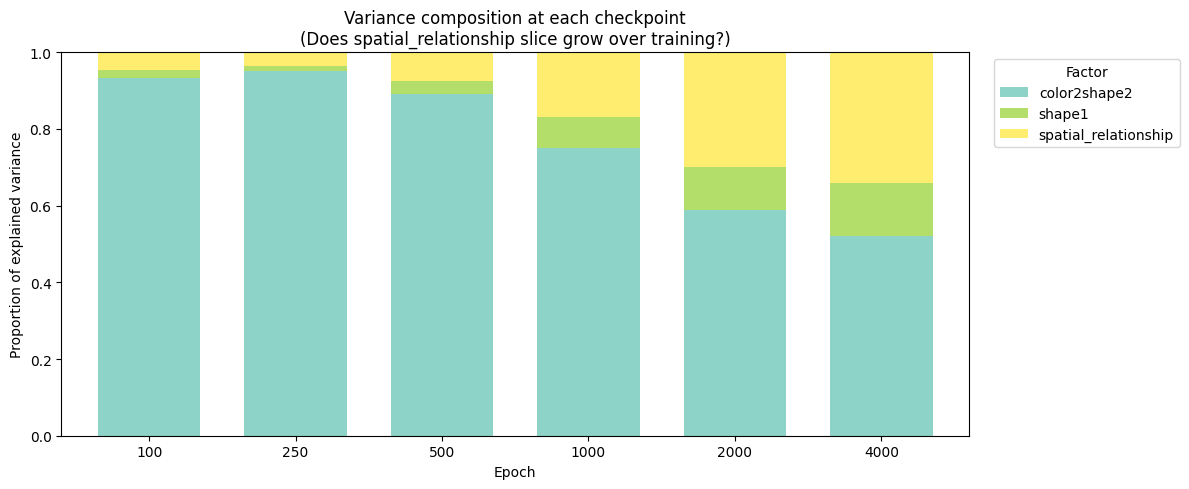

In [ ]:
# Exp 4: Stacked composition — how the variance "pie" changes across checkpoints
if var_part_df_evolution.empty:
    print("Run evolution loop (cell 32) first.")
else:
    vp = var_part_df_evolution
    vp_wide = vp.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
    vp_prop = vp_wide.div(vp_wide.sum(axis=1), axis=0)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    vp_prop.plot(kind="bar", stacked=True, ax=ax, width=0.7, colormap="Set3")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Proportion of explained variance")
    ax.set_title("Variance composition at each checkpoint\n(Does spatial_relationship slice grow over training?)")
    ax.legend(title="Factor", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xticklabels(vp_prop.index, rotation=0)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

### 3. Variance partition in MLP-projected embedding over time

R² explained by spatial_relationship, shape1, color2shape2 in the caption-projected word vectors.

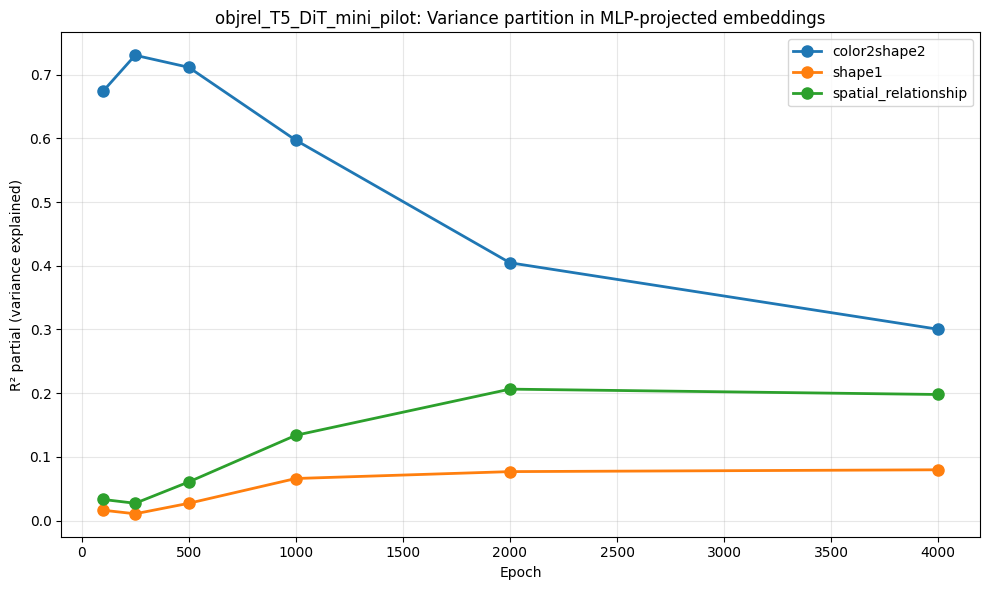

Spatial relationship R² by epoch:
epoch
100     0.033160
250     0.027142
500     0.060615
1000    0.133854
2000    0.206313
4000    0.197899


In [ ]:
# Variance partition: R² per factor over epochs
if var_part_df_evolution.empty or "feature" not in var_part_df_evolution.columns:
    print("Run the evolution loop (cell 32) first to populate variance partition data.")
else:
    vp_pivot = var_part_df_evolution.pivot_table(
        index="epoch", columns="feature", values="R2_partial", aggfunc="first"
    ).fillna(0)
    fig, ax = plt.subplots(figsize=(10, 6))
    for col in vp_pivot.columns:
        ax.plot(vp_pivot.index, vp_pivot[col], "o-", label=col, linewidth=2, markersize=8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("R² partial (variance explained)")
    ax.set_title(f"{model_run_name}: Variance partition in MLP-projected embeddings")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    if "spatial_relationship" in vp_pivot.columns:
        print("Spatial relationship R² by epoch:")
        print(vp_pivot["spatial_relationship"].to_string())

In [ ]:
# Reload final checkpoint so pipeline is ready for downstream cells (e.g., Test model)
ckpt = torch.load(join(ckptdir, "epoch_4000_step_160000.pth"), map_location="cpu", weights_only=False)
pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
del ckpt
gc.collect()
print("Reloaded epoch_4000 checkpoint.")

Reloaded epoch_4000 checkpoint.
